# Prediccion de energia solar generada
Dataset usado: https://www.kaggle.com/datasets/juanschafle/solarplant-power-generation-monitoring-2023-2025

C:\Users\aaran\AppData\Local\Temp\ipykernel_25716\3415368219.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y=target_col, data=df, palette='viridis', ax=axs[1, 1])


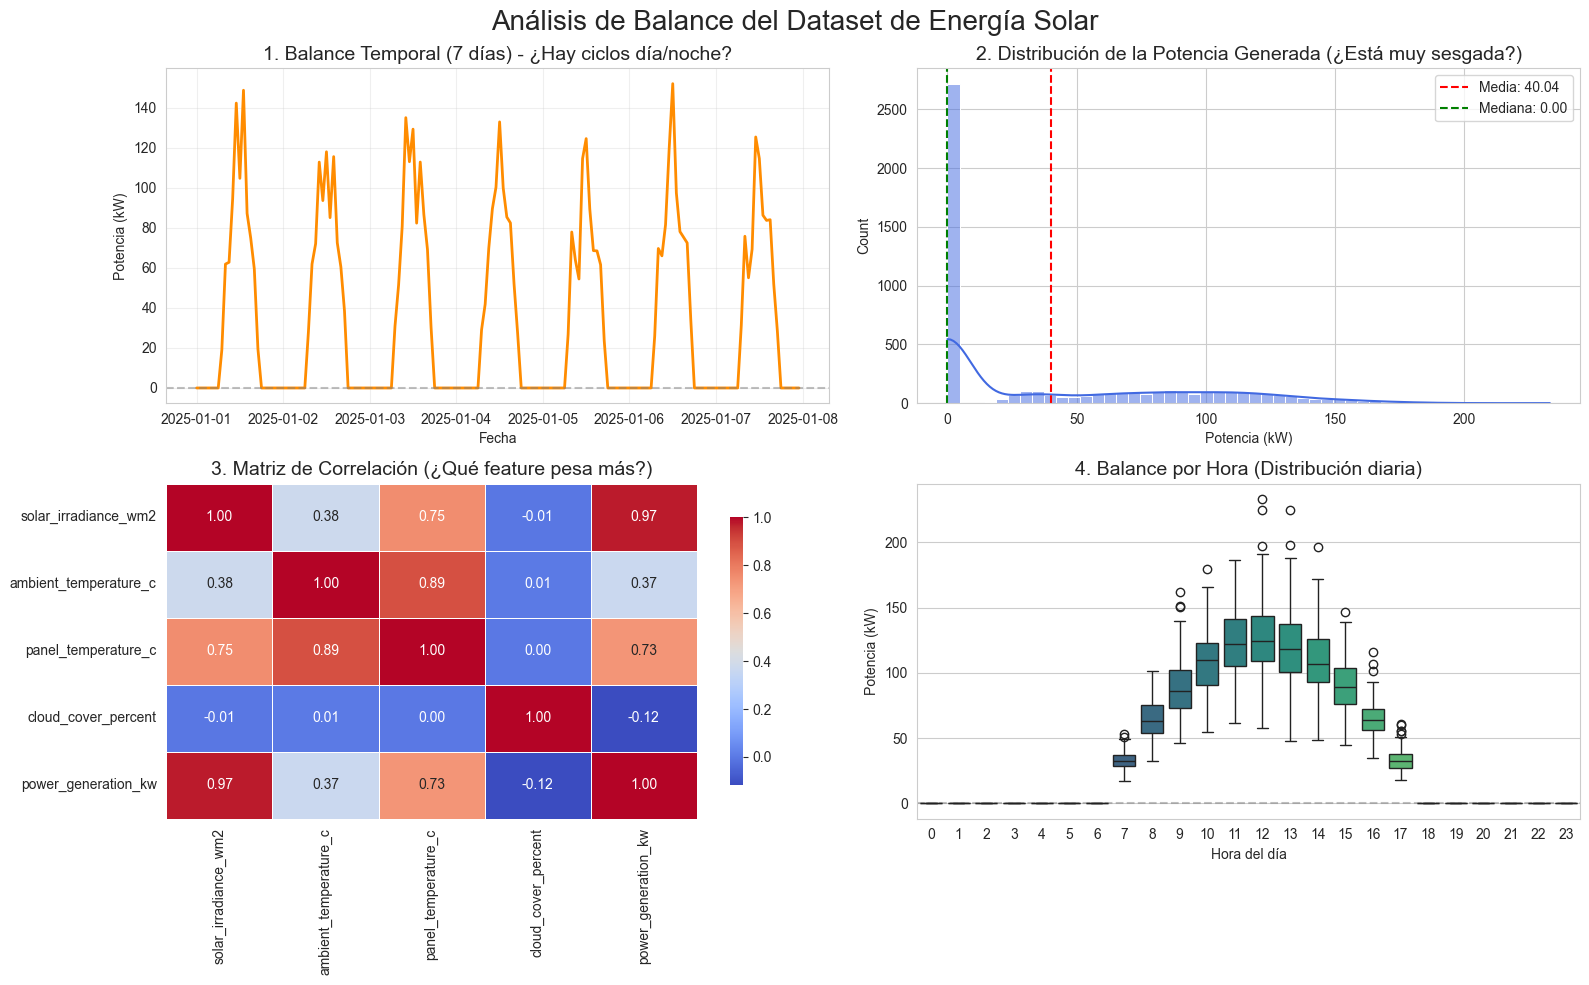


ESTADÍSTICAS DE BALANCE
Total de registros: 5000
Rango de fechas: 2025-01-01 00:00:00 -> 2025-07-28 07:00:00

Horas sin generación (Potencia = 0): 2711 (54.22%)
Horas con generación (>0): 2289 (45.78%)

Media de Potencia (cuando genera >0): 87.46243337702053
Mediana de Potencia: 0.0

Correlación con el target (Potencia):
solar_irradiance_wm2     0.974654
panel_temperature_c      0.732168
ambient_temperature_c    0.365665
cloud_cover_percent     -0.117163
Name: power_generation_kw, dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configurar estilo bonito
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# --- CARGAR TUS DATOS ---
df = pd.read_csv('C:/Users/aaran/Downloads/solar_plant_generation_dataset/solar_plant_generation_dataset.csv')

# --- AVERIGUAR SI TENEMOS COLUMNA DE FECHA ---
# Si el CSV tiene una columna llamada 'timestamp' o 'datetime', la usamos como índice
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
elif 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df.set_index('datetime', inplace=True)
else:
    # Si no hay columna de fecha, asumimos que los datos están ordenados y son horarios
    # Creamos un índice de fecha ficticio empezando en 2025-01-01 00:00
    print("No se encontró columna de fecha. Se creará un índice de tiempo ficticio.")
    df.index = pd.date_range(start='2025-01-01', periods=len(df), freq='H')

# Definir columnas (igual que en el código anterior)
feature_cols = ['solar_irradiance_wm2', 'ambient_temperature_c', 
                'panel_temperature_c', 'cloud_cover_percent']
target_col = 'power_generation_kw'

# --- CREAR LA FIGURA CON 4 SUBPLOTS ---
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis de Balance del Dataset de Energía Solar', fontsize=20, y=0.98)

# -----------------------------------------------
# GRÁFICO 1: Serie Temporal (Balance Día/Noche)
# -----------------------------------------------
# Tomamos una muestra de 7 días (168 horas) si hay suficientes datos
n_days = 7
sample = df.iloc[:min(168, len(df))]  # primeros 7 días o menos
axs[0, 0].plot(sample.index, sample[target_col], color='darkorange', linewidth=2)
axs[0, 0].set_title('1. Balance Temporal (7 días) - ¿Hay ciclos día/noche?', fontsize=14)
axs[0, 0].set_ylabel('Potencia (kW)')
axs[0, 0].set_xlabel('Fecha')
axs[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axs[0, 0].grid(True, alpha=0.3)

# -----------------------------------------------
# GRÁFICO 2: Distribución del Target
# -----------------------------------------------
sns.histplot(df[target_col], bins=50, kde=True, color='royalblue', ax=axs[0, 1])
axs[0, 1].set_title('2. Distribución de la Potencia Generada (¿Está muy sesgada?)', fontsize=14)
axs[0, 1].set_xlabel('Potencia (kW)')
axs[0, 1].axvline(x=df[target_col].mean(), color='red', linestyle='--', label=f'Media: {df[target_col].mean():.2f}')
axs[0, 1].axvline(x=df[target_col].median(), color='green', linestyle='--', label=f'Mediana: {df[target_col].median():.2f}')
axs[0, 1].legend()

# -----------------------------------------------
# GRÁFICO 3: Correlación entre Features
# -----------------------------------------------
corr_matrix = df[feature_cols + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axs[1, 0])
axs[1, 0].set_title('3. Matriz de Correlación (¿Qué feature pesa más?)', fontsize=14)

# -----------------------------------------------
# GRÁFICO 4: Balance por Hora del Día (Boxplot)
# -----------------------------------------------
# Extraemos la hora del índice (ahora sí es DatetimeIndex)
df['hour'] = df.index.hour
# Boxplot de potencia por hora
sns.boxplot(x='hour', y=target_col, data=df, palette='viridis', ax=axs[1, 1])
axs[1, 1].set_title('4. Balance por Hora (Distribución diaria)', fontsize=14)
axs[1, 1].set_xlabel('Hora del día')
axs[1, 1].set_ylabel('Potencia (kW)')
axs[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('balance_dataset.png', dpi=300)
plt.show()

# -----------------------------------------------
# RESULTADOS ESTADÍSTICOS
# -----------------------------------------------
print("\n" + "="*50)
print("ESTADÍSTICAS DE BALANCE")
print("="*50)
print(f"Total de registros: {len(df)}")
print(f"Rango de fechas: {df.index.min()} -> {df.index.max()}")

# Porcentaje de ceros
zeros = (df[target_col] == 0).sum()
total = len(df)
print(f"\nHoras sin generación (Potencia = 0): {zeros} ({zeros/total*100:.2f}%)")
print(f"Horas con generación (>0): {total-zeros} ({(total-zeros)/total*100:.2f}%)")

print("\nMedia de Potencia (cuando genera >0):", df[df[target_col] > 0][target_col].mean())
print("Mediana de Potencia:", df[target_col].median())

# Correlación más fuerte
corr_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
print("\nCorrelación con el target (Potencia):")
print(corr_target)


VALORES NULOS POR COLUMNA
solar_irradiance_wm2     0
ambient_temperature_c    0
panel_temperature_c      0
cloud_cover_percent      0
power_generation_kw      0
dtype: int64


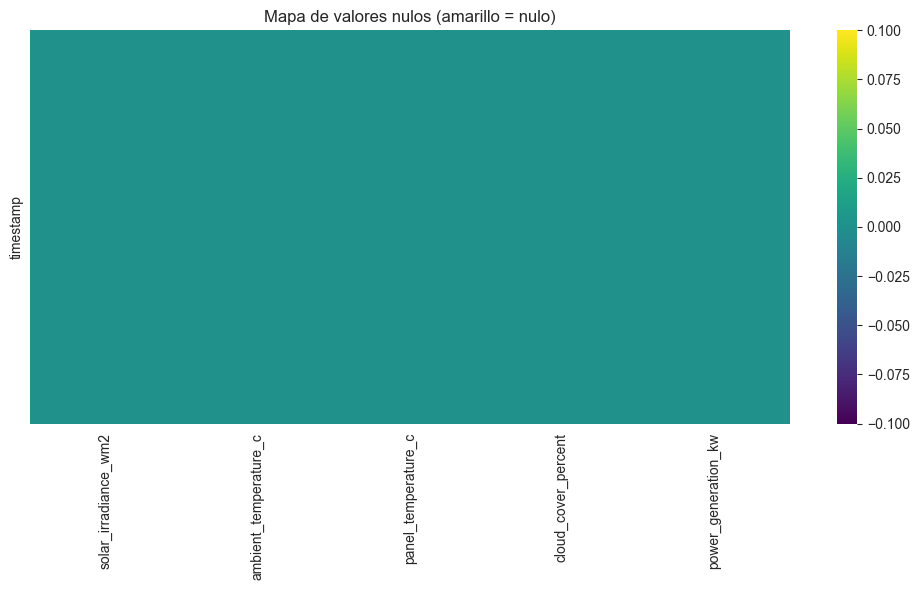

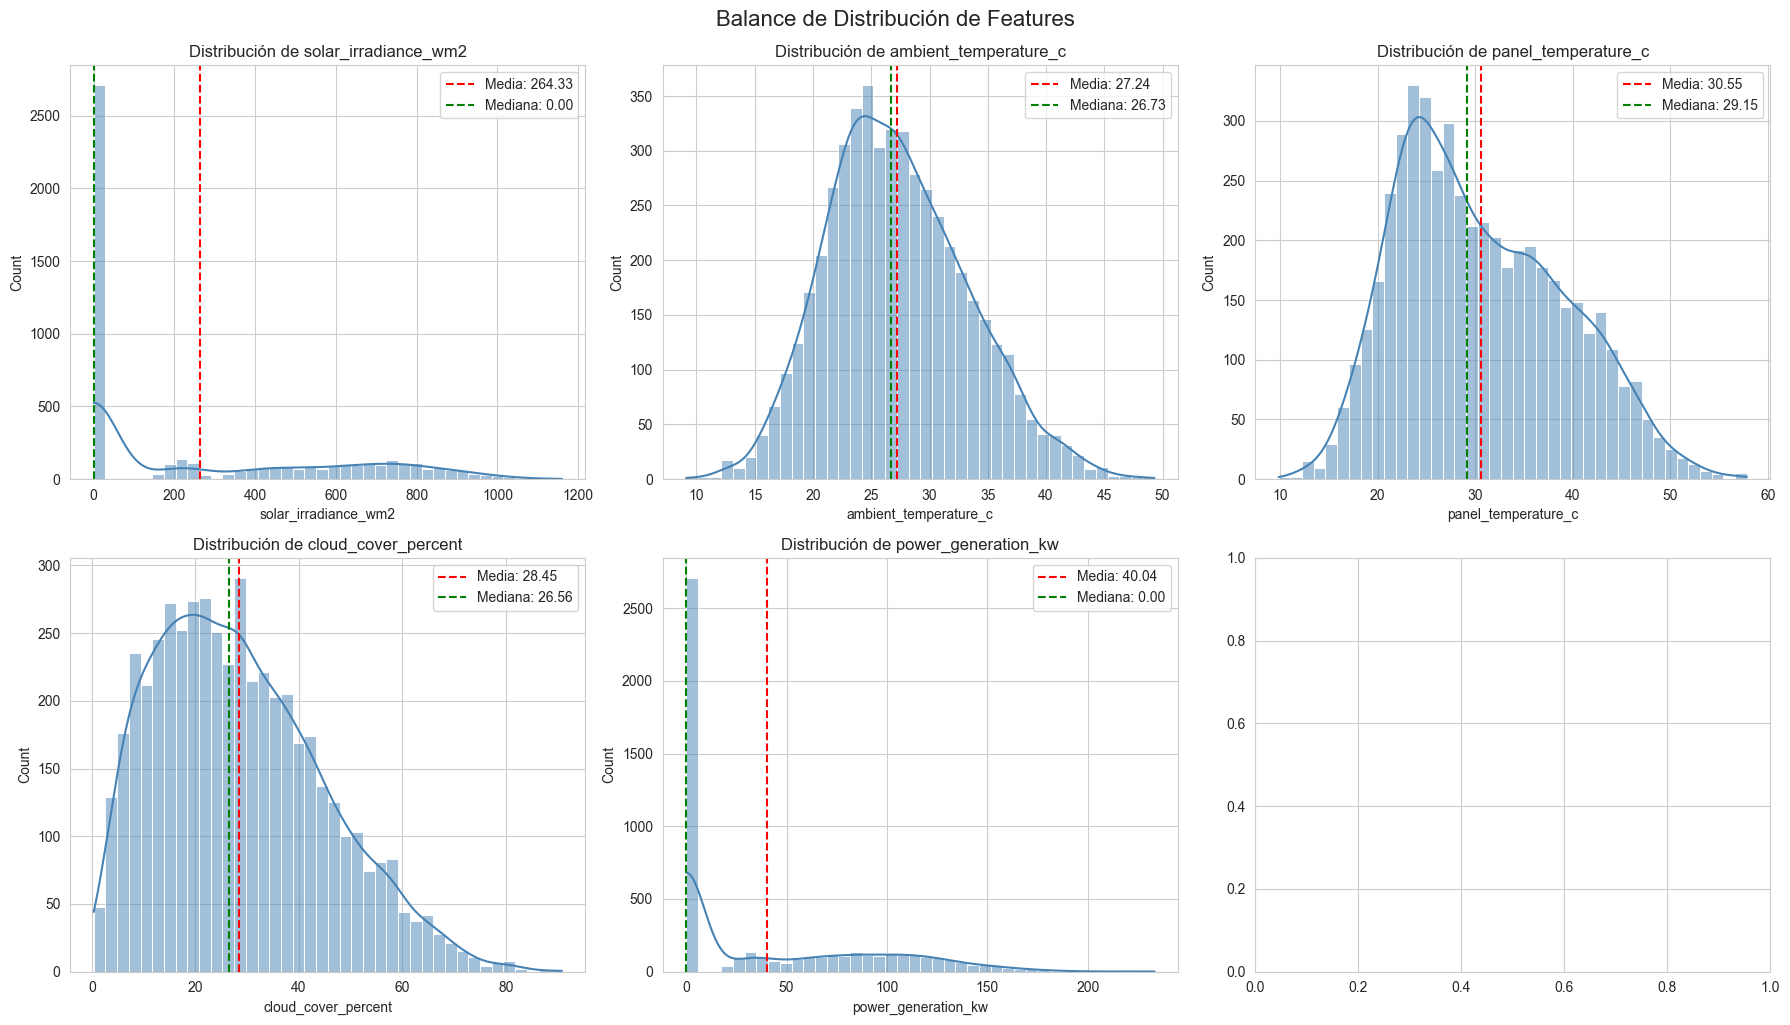

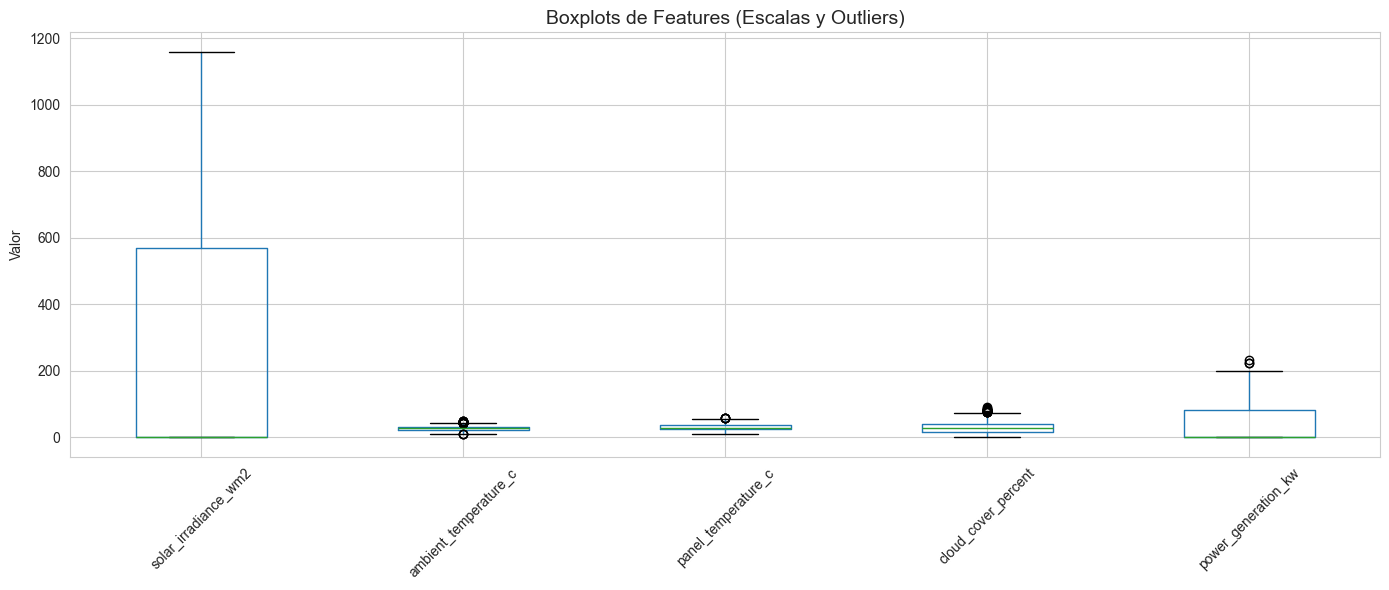

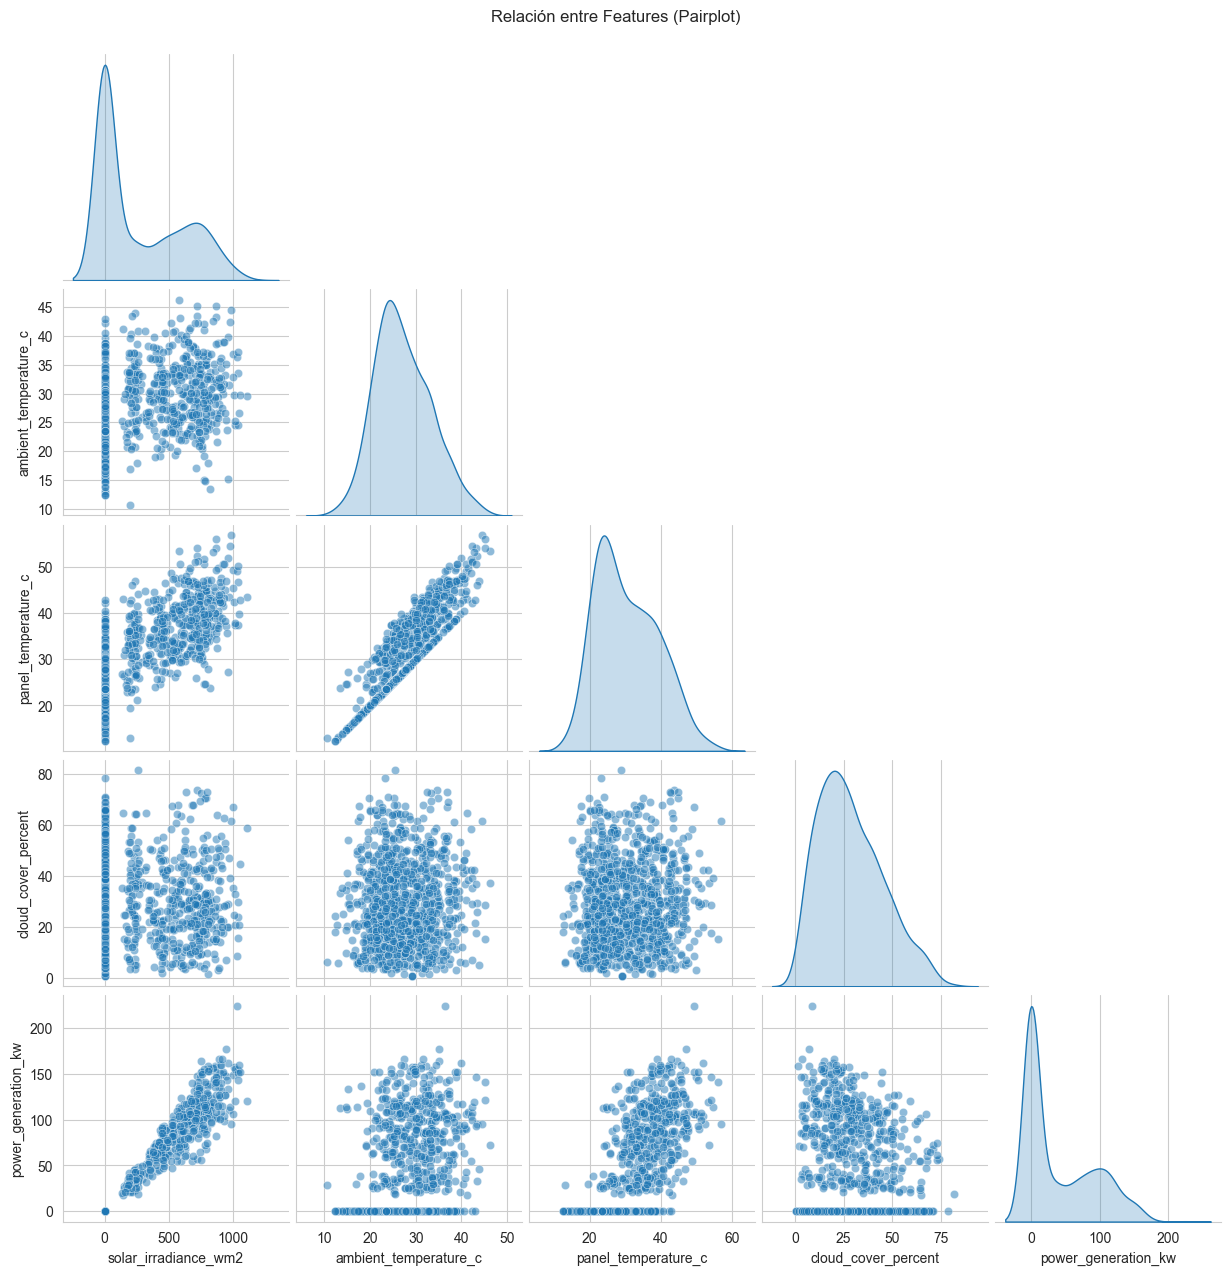

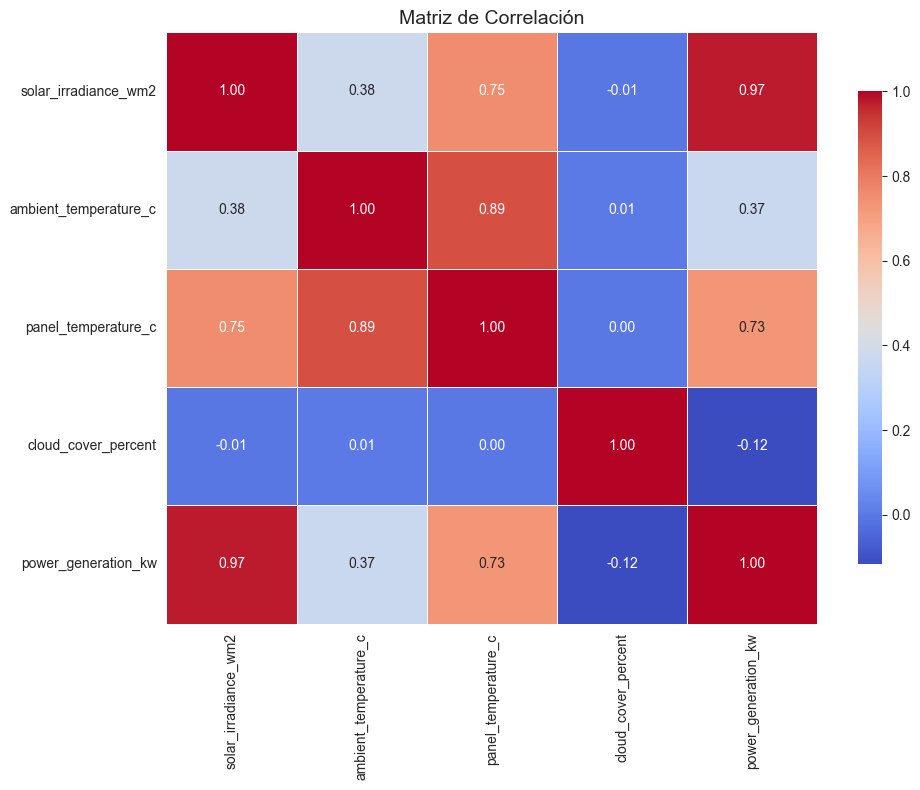

C:\Users\aaran\AppData\Local\Temp\ipykernel_25716\2641809241.py:143: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y=target_col, data=df, palette='viridis', ax=axs[1, 1])


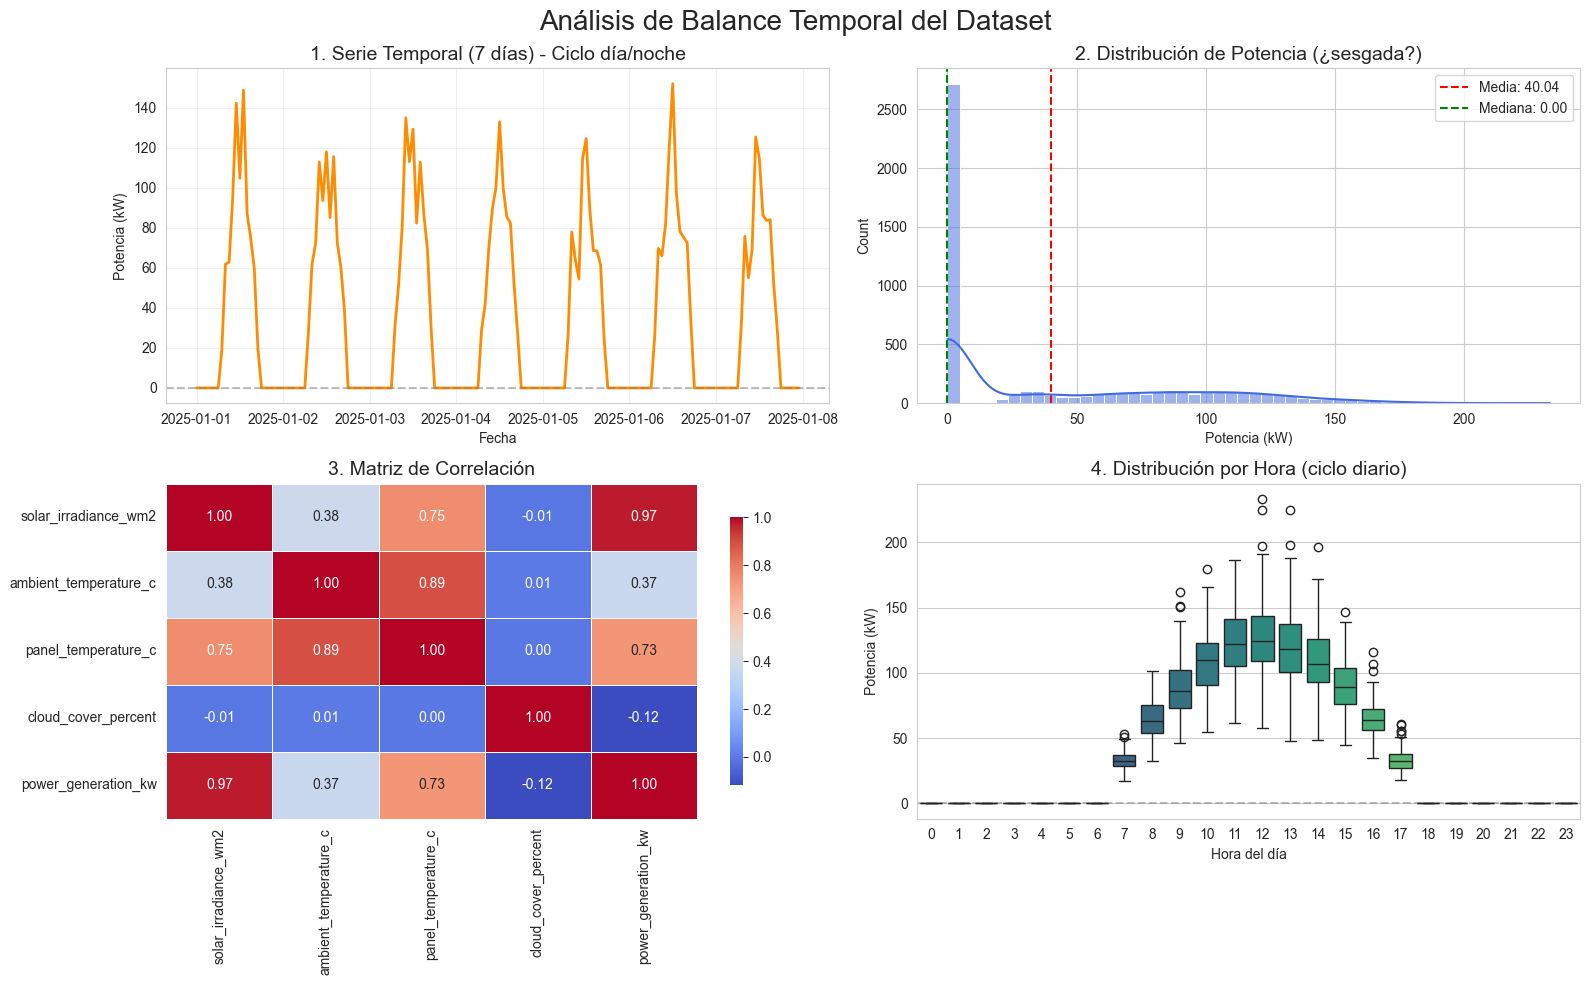


ESTADÍSTICAS DE BALANCE
Total de registros: 5000
Rango de fechas: 2025-01-01 00:00:00 -> 2025-07-28 07:00:00

Horas sin generación (Potencia = 0): 2711 (54.22%)
Horas con generación (>0): 2289 (45.78%)

Media de Potencia (cuando genera >0): 87.46243337702053
Mediana de Potencia: 0.0

Correlación con el target (Potencia):
solar_irradiance_wm2     0.974654
panel_temperature_c      0.732168
ambient_temperature_c    0.365665
cloud_cover_percent     -0.117163
Name: power_generation_kw, dtype: float64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# --------------------------------------------
# 1. CARGAR DATOS CON PARSEO DE FECHA
# --------------------------------------------
# Intenta leer el CSV parseando la columna de timestamp.
# Si tu columna se llama 'timestamp' o 'date', ajústalo.
df = pd.read_csv('C:/Users/aaran/Downloads/solar_plant_generation_dataset/solar_plant_generation_dataset.csv',
                 parse_dates=['timestamp'])  # <--- Ajusta el nombre de la columna de fecha

# Si no tienes columna de fecha, usa esto en su lugar:
# df = pd.read_csv('...')
# df['timestamp'] = pd.date_range(start='2025-01-01', periods=len(df), freq='H')
# df.set_index('timestamp', inplace=True)

# Verificar si se estableció correctamente el índice
if not isinstance(df.index, pd.DatetimeIndex):
    # Si no se pudo, intentamos con la columna 'timestamp' (si existe)
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
    else:
        # Si no hay columna de fecha, creamos un índice horario ficticio (solo para visualización)
        print("No se encontró columna de fecha. Se creará un índice secuencial.")
        df.index = pd.date_range(start='2025-01-01', periods=len(df), freq='H')

# Definir columnas (ajusta si tu CSV tiene nombres distintos)
feature_cols = ['solar_irradiance_wm2', 'ambient_temperature_c', 
                'panel_temperature_c', 'cloud_cover_percent']
target_col = 'power_generation_kw'

# Verificar que todas las columnas existan
missing_cols = [col for col in feature_cols + [target_col] if col not in df.columns]
if missing_cols:
    print(f"Columnas faltantes: {missing_cols}")
    print("Columnas disponibles:", df.columns.tolist())
    # Si el nombre de las columnas es diferente, ajústalo aquí.

# --------------------------------------------
# 2. ANÁLISIS DE VALORES NULOS
# --------------------------------------------
print("\n" + "="*50)
print("VALORES NULOS POR COLUMNA")
print("="*50)
print(df[feature_cols + [target_col]].isnull().sum())

# Visualizar nulos (mapa de calor)
plt.figure(figsize=(10, 6))
sns.heatmap(df[feature_cols + [target_col]].isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Mapa de valores nulos (amarillo = nulo)')
plt.tight_layout()
plt.show()

# Si hay nulos, decide cómo tratarlos (rellenar o eliminar)
# Ejemplo: rellenar con forward fill (sentido temporal)
df[feature_cols + [target_col]] = df[feature_cols + [target_col]].ffill().bfill()

# --------------------------------------------
# 3. DISTRIBUCIÓN DE CADA FEATURE (HISTOGRAMAS + BOXPLOTS)
# --------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Histogramas de cada feature
for i, col in enumerate(feature_cols + [target_col]):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Media: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Balance de Distribución de Features', fontsize=16, y=1.02)
plt.show()

# Boxplots para visualizar escalas y outliers
fig, ax = plt.subplots(figsize=(14, 6))
df[feature_cols + [target_col]].boxplot(ax=ax, rot=45, grid=True)
ax.set_title('Boxplots de Features (Escalas y Outliers)', fontsize=14)
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

# --------------------------------------------
# 4. RELACIÓN ENTRE FEATURES (PAIRPLOT / MATRIZ DE CORRELACIÓN)
# --------------------------------------------
# Pairplot con muestra de 1000 puntos para no saturar
sample_df = df[feature_cols + [target_col]].sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample_df, diag_kind='kde', corner=True, plot_kws={'alpha':0.5})
plt.suptitle('Relación entre Features (Pairplot)', y=1.02)
plt.show()

# Matriz de correlación (ya la tenías, la mantenemos)
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_cols + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 5. GRÁFICAS DE BALANCE TEMPORAL (como antes, pero corregido)
# --------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis de Balance Temporal del Dataset', fontsize=20, y=0.98)

# Serie temporal (7 días)
sample_7d = df.iloc[:168]  # primeras 168 horas (7 días)
axs[0, 0].plot(sample_7d.index, sample_7d[target_col], color='darkorange', linewidth=2)
axs[0, 0].set_title('1. Serie Temporal (7 días) - Ciclo día/noche', fontsize=14)
axs[0, 0].set_ylabel('Potencia (kW)')
axs[0, 0].set_xlabel('Fecha')
axs[0, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axs[0, 0].grid(True, alpha=0.3)

# Distribución del target
sns.histplot(df[target_col], bins=50, kde=True, color='royalblue', ax=axs[0, 1])
axs[0, 1].set_title('2. Distribución de Potencia (¿sesgada?)', fontsize=14)
axs[0, 1].set_xlabel('Potencia (kW)')
axs[0, 1].axvline(x=df[target_col].mean(), color='red', linestyle='--', 
                  label=f'Media: {df[target_col].mean():.2f}')
axs[0, 1].axvline(x=df[target_col].median(), color='green', linestyle='--', 
                  label=f'Mediana: {df[target_col].median():.2f}')
axs[0, 1].legend()

# Correlación (ya la mostramos antes, pero la repetimos para tener todo junto)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axs[1, 0])
axs[1, 0].set_title('3. Matriz de Correlación', fontsize=14)

# Boxplot por hora del día (ahora sí, porque tenemos índice datetime)
if isinstance(df.index, pd.DatetimeIndex):
    df['hour'] = df.index.hour
    sns.boxplot(x='hour', y=target_col, data=df, palette='viridis', ax=axs[1, 1])
    axs[1, 1].set_title('4. Distribución por Hora (ciclo diario)', fontsize=14)
    axs[1, 1].set_xlabel('Hora del día')
    axs[1, 1].set_ylabel('Potencia (kW)')
    axs[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
else:
    axs[1, 1].text(0.5, 0.5, 'No se pudo extraer hora\n(índice no datetime)', 
                   ha='center', va='center', transform=axs[1, 1].transAxes)
    axs[1, 1].set_title('4. No disponible')

plt.tight_layout()
plt.savefig('balance_completo.png', dpi=300)
plt.show()

# --------------------------------------------
# 6. ESTADÍSTICAS DE BALANCE (numéricas)
# --------------------------------------------
print("\n" + "="*50)
print("ESTADÍSTICAS DE BALANCE")
print("="*50)
print(f"Total de registros: {len(df)}")
print(f"Rango de fechas: {df.index.min()} -> {df.index.max()}")

# Porcentaje de ceros en potencia
zeros = (df[target_col] == 0).sum()
total = len(df)
print(f"\nHoras sin generación (Potencia = 0): {zeros} ({zeros/total*100:.2f}%)")
print(f"Horas con generación (>0): {total-zeros} ({(total-zeros)/total*100:.2f}%)")

print("\nMedia de Potencia (cuando genera >0):", df[df[target_col] > 0][target_col].mean())
print("Mediana de Potencia:", df[target_col].median())

# Correlación más fuerte
corr_target = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
print("\nCorrelación con el target (Potencia):")
print(corr_target)

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/aaran/Downloads/solar_plant_generation_dataset/solar_plant_generation_dataset.csv')

feature_cols = ['solar_irradiance_wm2', 'ambient_temperature_c', 
                'panel_temperature_c', 'cloud_cover_percent']

target_col = 'power_generation_kw'

data = df[feature_cols + [target_col]].values  # Forma: (muestras, 5)

data

array([[  0.  ,  23.06,  23.06,  35.37,   0.  ],
       [  0.  ,  28.04,  28.04,  20.7 ,   0.  ],
       [  0.  ,  24.97,  24.97,  16.  ,   0.  ],
       ...,
       [  0.  ,  22.87,  22.87,  15.66,   0.  ],
       [  0.  ,  24.88,  24.88,  48.95,   0.  ],
       [179.05,  32.52,  34.76,  46.07,  23.83]], shape=(5000, 5))

In [34]:
scaler = StandardScaler()

# Ajustamos el scaler con TODAS las columnas de entrenamiento
train_data_scaled = scaler.fit_transform(train_data)

# Transformamos validación y test con el mismo scaler (sin hacer fit)
val_data_scaled = scaler.transform(val_data)
test_data_scaled = scaler.transform(test_data)

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

class DatasetEnergiaSolar(Dataset):
    def __init__(self, data, seq_len=24, pred_len=6, target_col_idx=4):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_idx = target_col_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # --- ENTRADA (X) ---
        # Tomamos 'seq_len' filas consecutivas de TODAS las columnas (5)
        X = self.data[idx : idx + self.seq_len]  # (seq_len, 5)
        
        # --- SALIDA (y) ---
        # Tomamos 'pred_len' filas, pero SOLO la columna de potencia (índice 4)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len, self.target_idx]
        # y tendrá forma (pred_len,)
        
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

    

In [36]:
seq_len = 24   # Usa las últimas 24 horas para predecir
pred_len = 6   # Quiere predecir las próximas 6 horas (por ejemplo)

# Instanciamos datasets
train_dataset = DatasetEnergiaSolar(train_data_scaled, seq_len, pred_len)
val_dataset = DatasetEnergiaSolar(val_data_scaled, seq_len, pred_len)
test_dataset = DatasetEnergiaSolar(test_data_scaled, seq_len, pred_len)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

# Verifica la forma de un batch
for X_batch, y_batch in train_loader:
    print(f"X_batch shape: {X_batch.shape}")  # torch.Size([64, 24, 5])
    print(f"y_batch shape: {y_batch.shape}")  # torch.Size([64, 6])
    break

X_batch shape: torch.Size([64, 24, 5])
y_batch shape: torch.Size([64, 6])


In [14]:
#Cargar dataset
seq_len = 24   # Usa las últimas 24 horas para predecir
pred_len = 6   # Quiere predecir las próximas 6 horas (por ejemplo)

# Instanciamos datasets
train_dataset = DatasetEnergiaSolar(train_data, seq_len, pred_len)
val_dataset = DatasetEnergiaSolar(val_data, seq_len, pred_len)
test_dataset = DatasetEnergiaSolar(test_data, seq_len, pred_len)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)


# Verifica la forma de un batch
for X_batch, y_batch in train_loader:
    print(f"X_batch shape: {X_batch.shape}")  # torch.Size([64, 24, 5])
    print(f"y_batch shape: {y_batch.shape}")  # torch.Size([64, 6])
    break

X_batch shape: torch.Size([64, 24, 5])
y_batch shape: torch.Size([64, 6])


In [41]:
import torch
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

def fit(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=10):
    """
    Entrena el modelo con early stopping.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    criterion = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        # --- Entrenamiento ---
        model.train()
        train_losses = []
        train_loss_last = []  # pérdida solo en el último paso (opcional)

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)                     # (batch, pred_len)
            loss = criterion(y_hat, y)           # MSE sobre todos los pasos
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            # Pérdida solo en el último paso (para monitoreo)
            last_step_loss = (y[:, -1] - y_hat[:, -1]).pow(2).mean().item()
            train_loss_last.append(last_step_loss)

        # --- Validación ---
        model.eval()
        val_losses = []
        val_loss_last = []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_losses.append(loss.item())
                last_step_loss = (y[:, -1] - y_hat[:, -1]).pow(2).mean().item()
                val_loss_last.append(last_step_loss)

        # --- Métricas de la época ---
        avg_train_loss = np.mean(train_losses)
        avg_train_last = np.mean(train_loss_last)
        avg_val_loss = np.mean(val_losses)
        avg_val_last = np.mean(val_loss_last)

        # --- Scheduler (basado en val_loss) ---
        scheduler.step(avg_val_loss)

        # --- Early stopping ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()  # guarda el mejor modelo
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping en época {epoch}")
                break

        # --- Actualizar barra (opcional, sin tqdm para claridad) ---
        print(f"Época {epoch:3d} | Train Loss: {avg_train_loss:.5f} | Train Last: {avg_train_last:.5f} | "
              f"Val Loss: {avg_val_loss:.5f} | Val Last: {avg_val_last:.5f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    # Cargar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Cargado el mejor modelo (val_loss = {:.5f})".format(best_val_loss))

    return model


def predict(model, dataloader):
    """
    Predice usando el dataloader (que debe devolver solo X, o tuplas (X, y)).
    Si devuelve (X, y), ignora y.
    """
    model.eval()
    model.to(device)
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            # Si el batch es una tupla, tomamos el primer elemento (X)
            if isinstance(batch, (tuple, list)):
                X = batch[0]
            else:
                X = batch
            X = X.to(device)
            pred = model(X)          # (batch, pred_len)
            predictions.append(pred.cpu())

    return torch.cat(predictions, dim=0) if predictions else torch.tensor([])

In [59]:
import torch.nn as nn
# ============================================
# 1. CLASE BASE (comparte el forward)
# ============================================
class BaseRNN(nn.Module):
    def __init__(self, rnn_cell, input_size, hidden_size, num_layers, output_size, dropout=0):
        super().__init__()
        self.rnn = rnn_cell(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)          # (batch, seq_len, hidden_size)
        last_out = out[:, -1, :]      # (batch, hidden_size)
        return self.fc(last_out)      # (batch, output_size)

In [51]:
class SimpleRNN(BaseRNN):
    def __init__(self, input_size=5, hidden_size=20, num_layers=2, output_size=6, dropout=0):
        super().__init__(nn.RNN, input_size, hidden_size, num_layers, output_size, dropout)

In [52]:
# Suponiendo que ya tienes train_loader y val_loader
model = DeepRNN(input_size=5, hidden_size=64, num_layers=2, output_size=6)

# Entrenar
model = fit(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=10)

# Predecir sobre test (dataloader de test)
test_preds = predict(model, test_loader)   # test_loader devuelve (X, y) pero predict ignora y

Época   1 | Train Loss: 0.40428 | Train Last: 0.46952 | Val Loss: 0.13377 | Val Last: 0.16550 | LR: 1.00e-03
Época   2 | Train Loss: 0.11568 | Train Last: 0.13098 | Val Loss: 0.08323 | Val Last: 0.08283 | LR: 1.00e-03
Época   3 | Train Loss: 0.09306 | Train Last: 0.09539 | Val Loss: 0.08421 | Val Last: 0.08105 | LR: 1.00e-03
Época   4 | Train Loss: 0.08844 | Train Last: 0.09059 | Val Loss: 0.07774 | Val Last: 0.07603 | LR: 1.00e-03
Época   5 | Train Loss: 0.08602 | Train Last: 0.08844 | Val Loss: 0.08213 | Val Last: 0.08571 | LR: 1.00e-03
Época   6 | Train Loss: 0.08937 | Train Last: 0.09310 | Val Loss: 0.07848 | Val Last: 0.07494 | LR: 1.00e-03
Época   7 | Train Loss: 0.08524 | Train Last: 0.08808 | Val Loss: 0.08137 | Val Last: 0.07883 | LR: 1.00e-03
Época   8 | Train Loss: 0.08168 | Train Last: 0.08432 | Val Loss: 0.08815 | Val Last: 0.08512 | LR: 1.00e-03
Época   9 | Train Loss: 0.08048 | Train Last: 0.08324 | Val Loss: 0.07487 | Val Last: 0.07303 | LR: 1.00e-03
Época  10 | Train L

Predicciones: (721, 6), Reales: (721, 6)

MÉTRICAS GLOBALES (todos los pasos)
MAE:  0.1287 kW
RMSE: 0.2352 kW
R²:   0.9271
MAPE: 459.62 %

MÉTRICAS POR HORIZONTE (paso a paso)
Step	MAE (kW)	RMSE (kW)
1	0.1274		0.2308
2	0.1285		0.2380
3	0.1290		0.2367
4	0.1286		0.2357
5	0.1297		0.2360
6	0.1287		0.2341


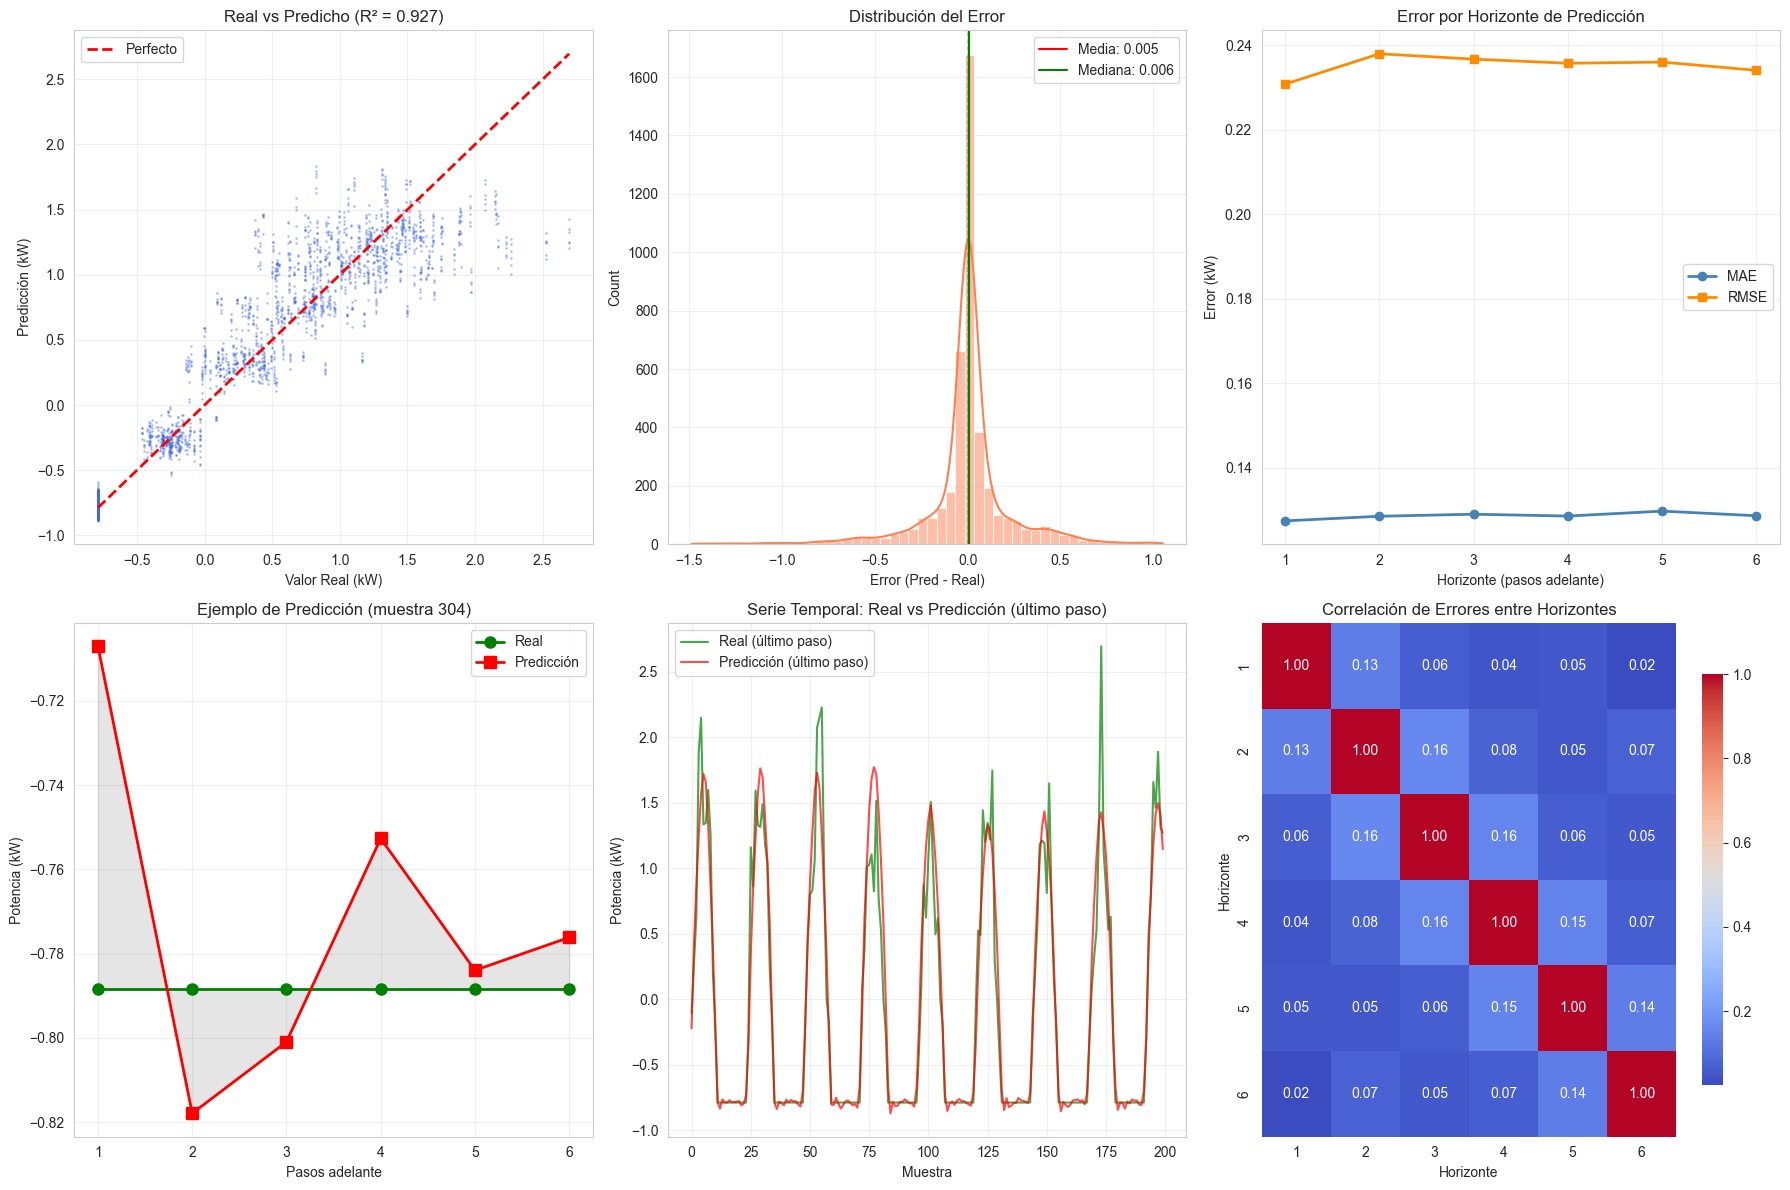

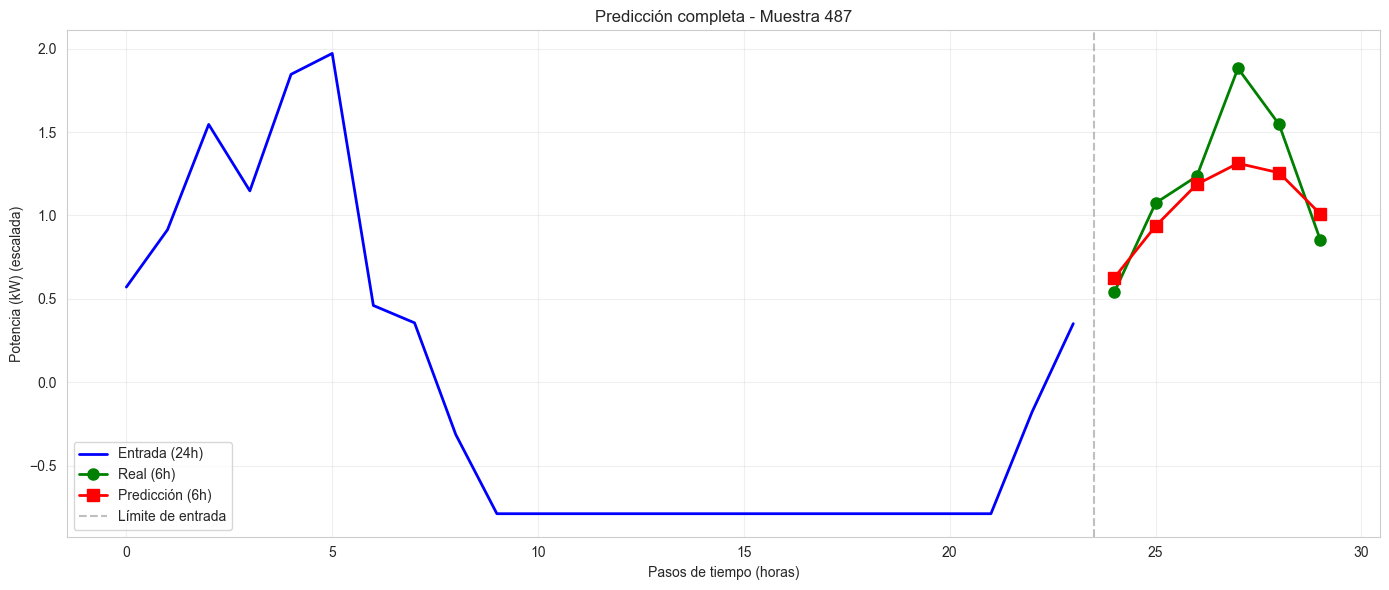

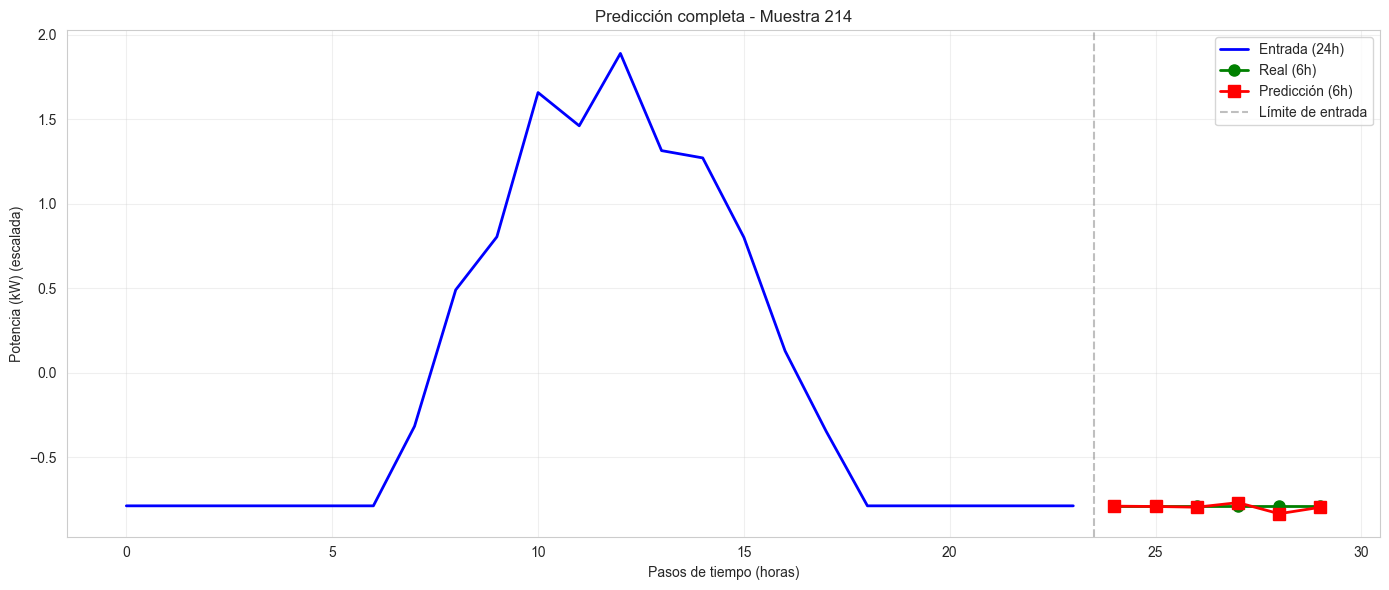

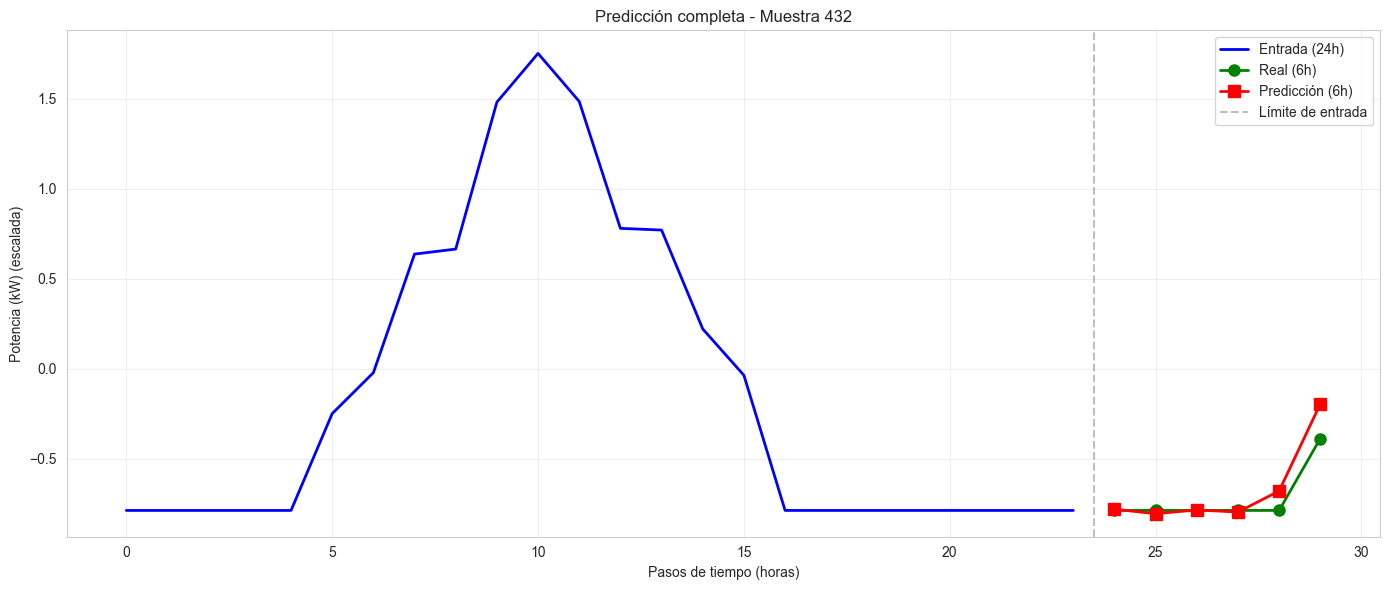

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# 1. OBTENER PREDICCIONES Y VALORES REALES
# ============================================
def get_predictions(model, dataloader, device='cuda'):
    """Devuelve arrays de predicciones y reales del dataloader."""
    model.eval()
    preds_list = []
    y_true_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)  # (batch, pred_len)
            
            preds_list.append(y_pred.cpu().numpy())
            y_true_list.append(y_batch.numpy())  # y_batch ya está en CPU
    
    # Concatenar todos los batches
    preds = np.concatenate(preds_list, axis=0)   # (n_muestras, pred_len)
    y_true = np.concatenate(y_true_list, axis=0) # (n_muestras, pred_len)
    
    return preds, y_true

# Obtener predicciones sobre test
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
preds, y_true = get_predictions(model, test_loader, device)

print(f"Predicciones: {preds.shape}, Reales: {y_true.shape}")

# ============================================
# 2. MÉTRICAS GLOBALES
# ============================================
# Aplanar para calcular métricas sobre todos los pasos
preds_flat = preds.flatten()
y_true_flat = y_true.flatten()

mae = mean_absolute_error(y_true_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, preds_flat))
r2 = r2_score(y_true_flat, preds_flat)

# MAPE (evita división por cero)
mape = np.mean(np.abs((y_true_flat - preds_flat) / (y_true_flat + 1e-8))) * 100

print("\n" + "="*50)
print("MÉTRICAS GLOBALES (todos los pasos)")
print("="*50)
print(f"MAE:  {mae:.4f} kW")
print(f"RMSE: {rmse:.4f} kW")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f} %")

# ============================================
# 3. MÉTRICAS POR HORIZONTE (paso a paso)
# ============================================
errors_step = []
for step in range(preds.shape[1]):
    mae_step = mean_absolute_error(y_true[:, step], preds[:, step])
    rmse_step = np.sqrt(mean_squared_error(y_true[:, step], preds[:, step]))
    errors_step.append((mae_step, rmse_step))

print("\nMÉTRICAS POR HORIZONTE (paso a paso)")
print("Step\tMAE (kW)\tRMSE (kW)")
for step, (mae_s, rmse_s) in enumerate(errors_step, 1):
    print(f"{step}\t{mae_s:.4f}\t\t{rmse_s:.4f}")

# ============================================
# 4. GRÁFICOS
# ============================================
fig = plt.figure(figsize=(18, 12))

# ---------- Gráfico 1: Real vs Predicho (scatter) ----------
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_true_flat, preds_flat, alpha=0.3, s=1, color='royalblue')
ax1.plot([y_true_flat.min(), y_true_flat.max()], 
         [y_true_flat.min(), y_true_flat.max()], 
         'r--', linewidth=2, label='Perfecto')
ax1.set_xlabel('Valor Real (kW)')
ax1.set_ylabel('Predicción (kW)')
ax1.set_title(f'Real vs Predicho (R² = {r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------- Gráfico 2: Distribución de errores ----------
ax2 = plt.subplot(2, 3, 2)
errors = preds_flat - y_true_flat
sns.histplot(errors, bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.axvline(x=np.mean(errors), color='red', linestyle='-', 
            label=f'Media: {np.mean(errors):.3f}')
ax2.axvline(x=np.median(errors), color='green', linestyle='-', 
            label=f'Mediana: {np.median(errors):.3f}')
ax2.set_xlabel('Error (Pred - Real)')
ax2.set_title('Distribución del Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ---------- Gráfico 3: Error por horizonte ----------
ax3 = plt.subplot(2, 3, 3)
steps = np.arange(1, preds.shape[1] + 1)
mae_steps = [e[0] for e in errors_step]
rmse_steps = [e[1] for e in errors_step]
ax3.plot(steps, mae_steps, 'o-', label='MAE', color='steelblue', linewidth=2)
ax3.plot(steps, rmse_steps, 's-', label='RMSE', color='darkorange', linewidth=2)
ax3.set_xlabel('Horizonte (pasos adelante)')
ax3.set_ylabel('Error (kW)')
ax3.set_title('Error por Horizonte de Predicción')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---------- Gráfico 4: Ejemplo de predicción (una muestra) ----------
ax4 = plt.subplot(2, 3, 4)
# Tomamos una muestra aleatoria del test
idx = np.random.randint(0, len(preds))
# Graficamos los 6 pasos predichos vs reales
x_steps = np.arange(1, preds.shape[1] + 1)
ax4.plot(x_steps, y_true[idx], 'o-', label='Real', color='green', linewidth=2, markersize=8)
ax4.plot(x_steps, preds[idx], 's-', label='Predicción', color='red', linewidth=2, markersize=8)
ax4.fill_between(x_steps, y_true[idx], preds[idx], alpha=0.2, color='gray')
ax4.set_xlabel('Pasos adelante')
ax4.set_ylabel('Potencia (kW)')
ax4.set_title(f'Ejemplo de Predicción (muestra {idx})')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---------- Gráfico 5: Serie temporal completa (200 muestras) ----------
ax5 = plt.subplot(2, 3, 5)
# Tomamos las primeras 200 muestras del test (equivalente a 200*24h si son horarias)
n_samples = min(200, len(preds))
time_index = np.arange(n_samples)
# Para graficar solo el último paso predicho (o el promedio de los 6)
# Mostramos el último paso (el más lejano en el tiempo) para ver la tendencia
last_step_pred = preds[:n_samples, -1]
last_step_true = y_true[:n_samples, -1]
ax5.plot(time_index, last_step_true, label='Real (último paso)', color='green', alpha=0.7)
ax5.plot(time_index, last_step_pred, label='Predicción (último paso)', color='red', alpha=0.7)
ax5.set_xlabel('Muestra')
ax5.set_ylabel('Potencia (kW)')
ax5.set_title(f'Serie Temporal: Real vs Predicción (último paso)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# ---------- Gráfico 6: Matriz de correlación de errores ----------
ax6 = plt.subplot(2, 3, 6)
# Calculamos correlación entre errores de diferentes pasos
error_matrix = preds - y_true  # (n_muestras, pred_len)
corr_errors = np.corrcoef(error_matrix, rowvar=False)
sns.heatmap(corr_errors, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={"shrink": 0.8}, ax=ax6)
ax6.set_xlabel('Horizonte')
ax6.set_ylabel('Horizonte')
ax6.set_title('Correlación de Errores entre Horizontes')
ax6.set_xticklabels(range(1, preds.shape[1]+1))
ax6.set_yticklabels(range(1, preds.shape[1]+1))

plt.tight_layout()
plt.savefig('predicciones_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. GRÁFICO ADICIONAL: COMPARACIÓN COMPLETA (ENTRADA + PREDICCIÓN)
# ============================================
# Para este gráfico necesitamos reconstruir la secuencia completa desde el dataset original.
# Asumimos que test_dataset guarda los índices originales o podemos obtener una muestra.

# Si quieres ver la entrada de 24h + predicción de 6h en una sola gráfica:
def plot_full_prediction(model, test_dataset, idx, device='cuda'):
    """
    Grafica la entrada (seq_len) y la predicción (pred_len) para una muestra dada.
    """
    X_sample, y_sample = test_dataset[idx]
    X_sample = X_sample.unsqueeze(0).to(device)  # (1, seq_len, 5)
    y_true = y_sample.numpy()  # (pred_len,)
    
    with torch.no_grad():
        y_pred = model(X_sample).squeeze().cpu().numpy()  # (pred_len,)
    
    # Reconstruir la secuencia: los features de entrada (la última columna es potencia)
    X_np = X_sample.squeeze().cpu().numpy()  # (seq_len, 5)
    # Graficamos solo la potencia de entrada (última columna)
    input_power = X_np[:, -1]  # potencia pasada
    # Los valores están escalados, necesitamos desescalar. (opcional: si guardaste el scaler)
    # Por simplicidad, graficamos en escala normalizada o puedes desescalar con scaler.inverse_transform
    
    plt.figure(figsize=(14, 6))
    plt.plot(np.arange(len(input_power)), input_power, label='Entrada (24h)', color='blue', linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_true)), 
             y_true, 'o-', label='Real (6h)', color='green', markersize=8, linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_pred)), 
             y_pred, 's-', label='Predicción (6h)', color='red', markersize=8, linewidth=2)
    plt.axvline(x=len(input_power)-0.5, color='gray', linestyle='--', alpha=0.5, label='Límite de entrada')
    plt.xlabel('Pasos de tiempo (horas)')
    plt.ylabel('Potencia (kW) (escalada)')
    plt.title(f'Predicción completa - Muestra {idx}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejemplo: graficar 3 muestras aleatorias
for i in np.random.choice(len(test_dataset), 3, replace=False):
    plot_full_prediction(model, test_dataset, i, device)

# LSTM

In [47]:
class LSTM(DeepRNN):
  def __init__(self, n_out=10, dropout=0):
    super().__init__()
    self.rnn = torch.nn.LSTM(input_size=1, hidden_size=20, num_layers=2, dropout=dropout, batch_first=True)

lstm = LSTM()
lstm

LSTM(
  (rnn): LSTM(1, 20, num_layers=2, batch_first=True)
  (fc): Linear(in_features=20, out_features=6, bias=True)
)

In [67]:
# Parámetros (ajusta según tu dataset)
input_size = 5        # número de features
hidden_size = 64      # tamaño del estado oculto
num_layers = 2        # número de capas RNN
output_size = 6       # pasos a predecir (pred_len)
dropout = 0.2         # dropout entre capas (solo si num_layers > 1)

class LSTM(BaseRNN):
    def __init__(self, input_size=5, hidden_size=20, num_layers=2, output_size=6, dropout=0):
        super().__init__(nn.LSTM, input_size, hidden_size, num_layers, output_size, dropout)

model_lstm = LSTM(input_size, hidden_size, num_layers, output_size, dropout)
model_lstm

LSTM(
  (rnn): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

In [68]:
# Entrenar
model = fit(model_lstm, train_loader, val_loader, epochs=100, lr=1e-3, patience=10)

# Predecir sobre test (dataloader de test)
test_preds = predict(model_lstm, test_loader)   # test_loader devuelve (X, y) pero predict ignora y

Época   1 | Train Loss: 0.54239 | Train Last: 0.46710 | Val Loss: 0.10708 | Val Last: 0.12107 | LR: 1.00e-03
Época   2 | Train Loss: 0.10158 | Train Last: 0.10442 | Val Loss: 0.07878 | Val Last: 0.07928 | LR: 1.00e-03
Época   3 | Train Loss: 0.08866 | Train Last: 0.08911 | Val Loss: 0.07536 | Val Last: 0.07518 | LR: 1.00e-03
Época   4 | Train Loss: 0.08307 | Train Last: 0.08346 | Val Loss: 0.07364 | Val Last: 0.07588 | LR: 1.00e-03
Época   5 | Train Loss: 0.08155 | Train Last: 0.08236 | Val Loss: 0.07384 | Val Last: 0.07440 | LR: 1.00e-03
Época   6 | Train Loss: 0.07991 | Train Last: 0.08144 | Val Loss: 0.07636 | Val Last: 0.07600 | LR: 1.00e-03
Época   7 | Train Loss: 0.07987 | Train Last: 0.08152 | Val Loss: 0.07340 | Val Last: 0.07316 | LR: 1.00e-03
Época   8 | Train Loss: 0.07999 | Train Last: 0.08261 | Val Loss: 0.07602 | Val Last: 0.07359 | LR: 1.00e-03
Época   9 | Train Loss: 0.07936 | Train Last: 0.08083 | Val Loss: 0.07429 | Val Last: 0.07418 | LR: 1.00e-03
Época  10 | Train L

Predicciones: (721, 6), Reales: (721, 6)

MÉTRICAS GLOBALES (todos los pasos)
MAE:  0.1277 kW
RMSE: 0.2360 kW
R²:   0.9267
MAPE: 458.83 %

MÉTRICAS POR HORIZONTE (paso a paso)
Step	MAE (kW)	RMSE (kW)
1	0.1315		0.2401
2	0.1267		0.2368
3	0.1235		0.2330
4	0.1249		0.2347
5	0.1281		0.2346
6	0.1315		0.2366


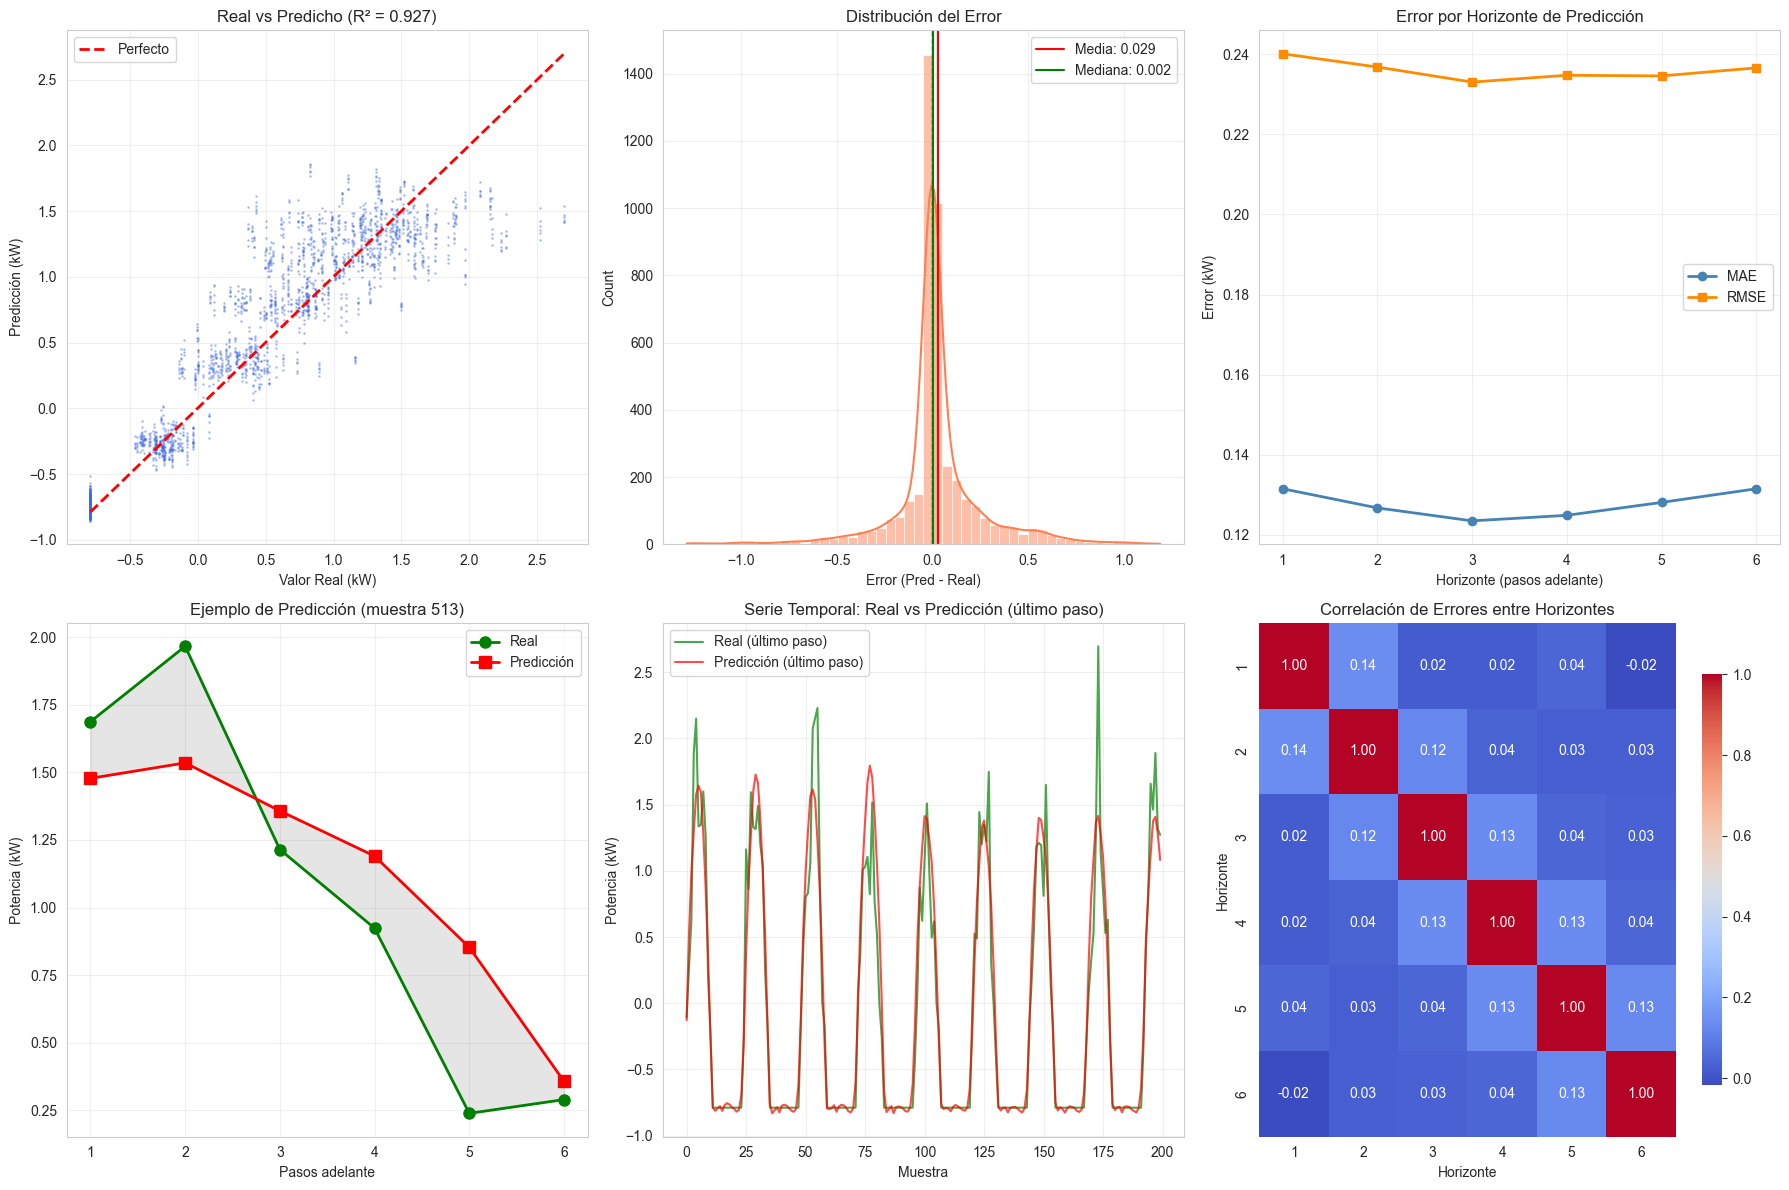

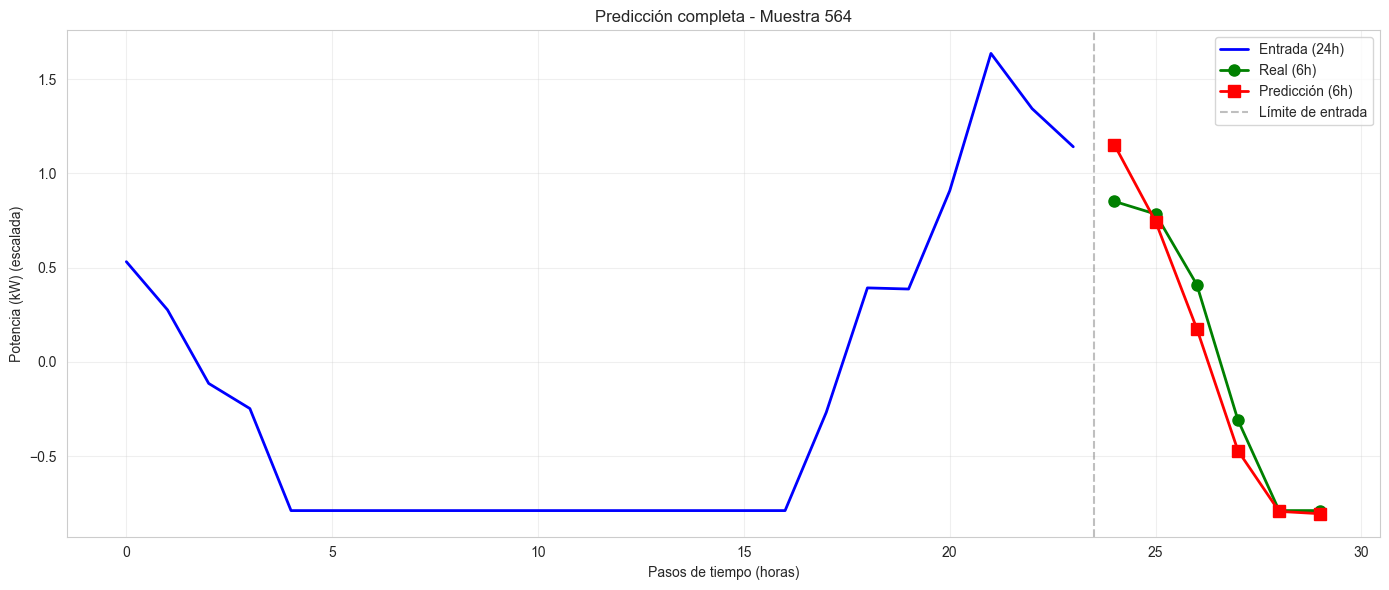

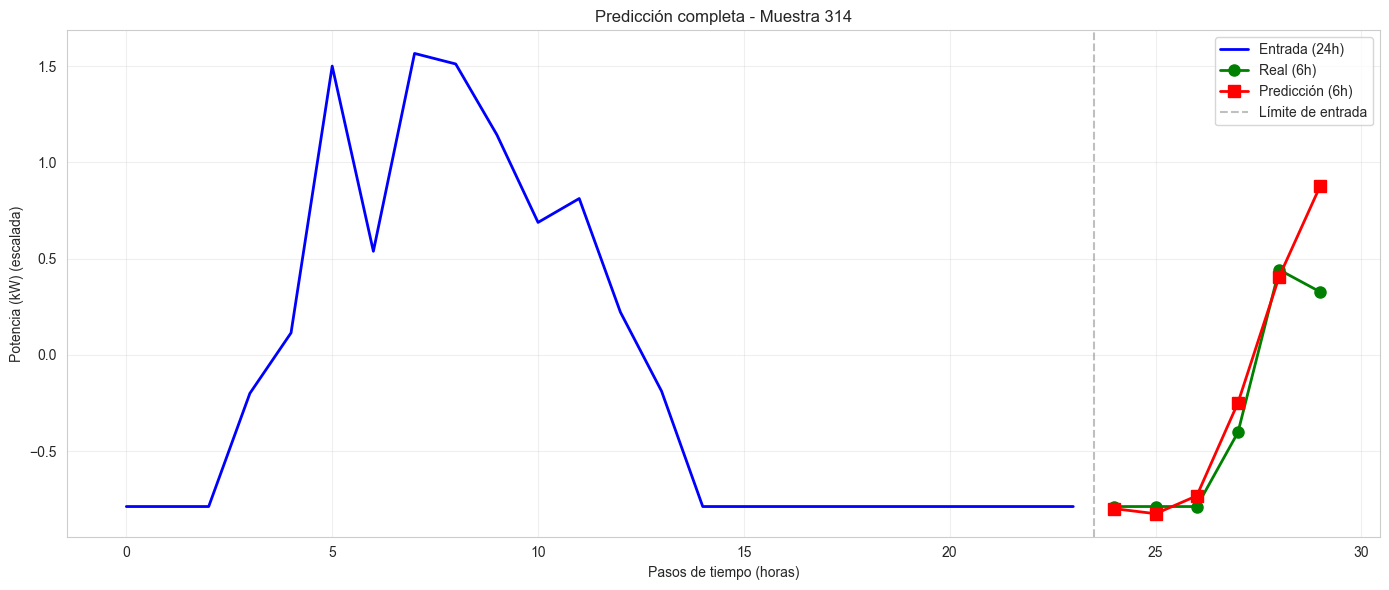

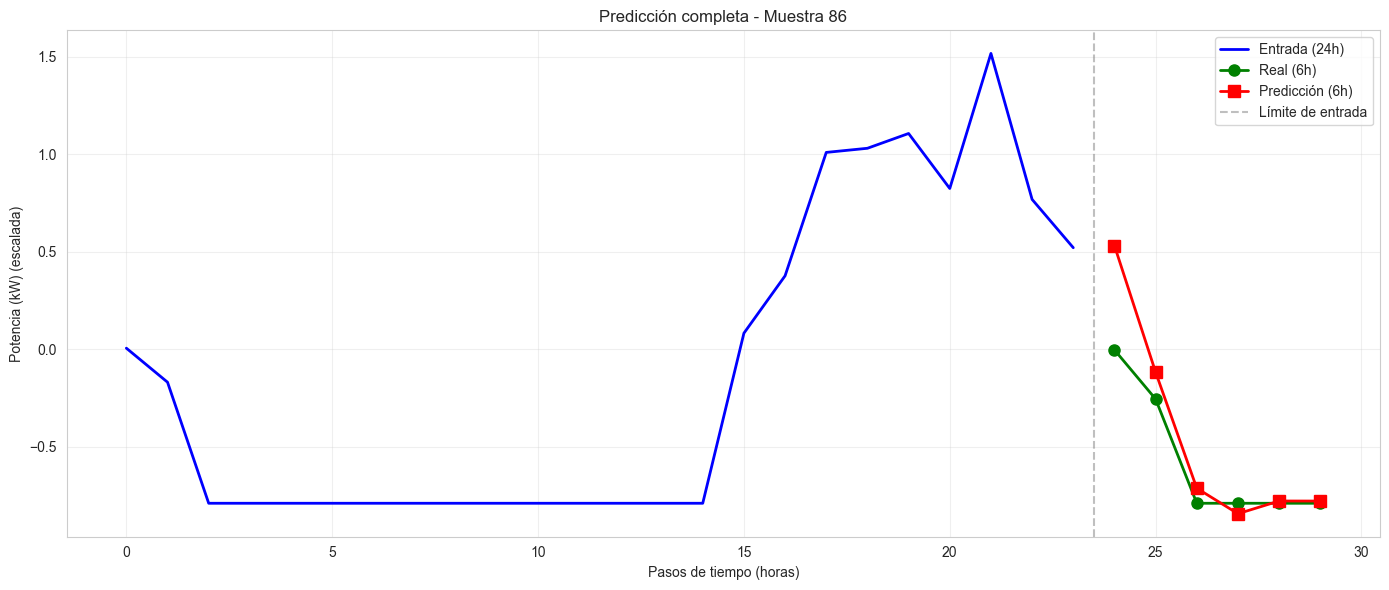

In [69]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# 1. OBTENER PREDICCIONES Y VALORES REALES
# ============================================
def get_predictions(model, dataloader, device='cuda'):
    """Devuelve arrays de predicciones y reales del dataloader."""
    model.eval()
    preds_list = []
    y_true_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)  # (batch, pred_len)
            
            preds_list.append(y_pred.cpu().numpy())
            y_true_list.append(y_batch.numpy())  # y_batch ya está en CPU
    
    # Concatenar todos los batches
    preds = np.concatenate(preds_list, axis=0)   # (n_muestras, pred_len)
    y_true = np.concatenate(y_true_list, axis=0) # (n_muestras, pred_len)
    
    return preds, y_true

# Obtener predicciones sobre test
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
preds, y_true = get_predictions(model, test_loader, device)

print(f"Predicciones: {preds.shape}, Reales: {y_true.shape}")

# ============================================
# 2. MÉTRICAS GLOBALES
# ============================================
# Aplanar para calcular métricas sobre todos los pasos
preds_flat = preds.flatten()
y_true_flat = y_true.flatten()

mae = mean_absolute_error(y_true_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, preds_flat))
r2 = r2_score(y_true_flat, preds_flat)

# MAPE (evita división por cero)
mape = np.mean(np.abs((y_true_flat - preds_flat) / (y_true_flat + 1e-8))) * 100

print("\n" + "="*50)
print("MÉTRICAS GLOBALES (todos los pasos)")
print("="*50)
print(f"MAE:  {mae:.4f} kW")
print(f"RMSE: {rmse:.4f} kW")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f} %")

# ============================================
# 3. MÉTRICAS POR HORIZONTE (paso a paso)
# ============================================
errors_step = []
for step in range(preds.shape[1]):
    mae_step = mean_absolute_error(y_true[:, step], preds[:, step])
    rmse_step = np.sqrt(mean_squared_error(y_true[:, step], preds[:, step]))
    errors_step.append((mae_step, rmse_step))

print("\nMÉTRICAS POR HORIZONTE (paso a paso)")
print("Step\tMAE (kW)\tRMSE (kW)")
for step, (mae_s, rmse_s) in enumerate(errors_step, 1):
    print(f"{step}\t{mae_s:.4f}\t\t{rmse_s:.4f}")

# ============================================
# 4. GRÁFICOS
# ============================================
fig = plt.figure(figsize=(18, 12))

# ---------- Gráfico 1: Real vs Predicho (scatter) ----------
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_true_flat, preds_flat, alpha=0.3, s=1, color='royalblue')
ax1.plot([y_true_flat.min(), y_true_flat.max()], 
         [y_true_flat.min(), y_true_flat.max()], 
         'r--', linewidth=2, label='Perfecto')
ax1.set_xlabel('Valor Real (kW)')
ax1.set_ylabel('Predicción (kW)')
ax1.set_title(f'Real vs Predicho (R² = {r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------- Gráfico 2: Distribución de errores ----------
ax2 = plt.subplot(2, 3, 2)
errors = preds_flat - y_true_flat
sns.histplot(errors, bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.axvline(x=np.mean(errors), color='red', linestyle='-', 
            label=f'Media: {np.mean(errors):.3f}')
ax2.axvline(x=np.median(errors), color='green', linestyle='-', 
            label=f'Mediana: {np.median(errors):.3f}')
ax2.set_xlabel('Error (Pred - Real)')
ax2.set_title('Distribución del Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ---------- Gráfico 3: Error por horizonte ----------
ax3 = plt.subplot(2, 3, 3)
steps = np.arange(1, preds.shape[1] + 1)
mae_steps = [e[0] for e in errors_step]
rmse_steps = [e[1] for e in errors_step]
ax3.plot(steps, mae_steps, 'o-', label='MAE', color='steelblue', linewidth=2)
ax3.plot(steps, rmse_steps, 's-', label='RMSE', color='darkorange', linewidth=2)
ax3.set_xlabel('Horizonte (pasos adelante)')
ax3.set_ylabel('Error (kW)')
ax3.set_title('Error por Horizonte de Predicción')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---------- Gráfico 4: Ejemplo de predicción (una muestra) ----------
ax4 = plt.subplot(2, 3, 4)
# Tomamos una muestra aleatoria del test
idx = np.random.randint(0, len(preds))
# Graficamos los 6 pasos predichos vs reales
x_steps = np.arange(1, preds.shape[1] + 1)
ax4.plot(x_steps, y_true[idx], 'o-', label='Real', color='green', linewidth=2, markersize=8)
ax4.plot(x_steps, preds[idx], 's-', label='Predicción', color='red', linewidth=2, markersize=8)
ax4.fill_between(x_steps, y_true[idx], preds[idx], alpha=0.2, color='gray')
ax4.set_xlabel('Pasos adelante')
ax4.set_ylabel('Potencia (kW)')
ax4.set_title(f'Ejemplo de Predicción (muestra {idx})')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---------- Gráfico 5: Serie temporal completa (200 muestras) ----------
ax5 = plt.subplot(2, 3, 5)
# Tomamos las primeras 200 muestras del test (equivalente a 200*24h si son horarias)
n_samples = min(200, len(preds))
time_index = np.arange(n_samples)
# Para graficar solo el último paso predicho (o el promedio de los 6)
# Mostramos el último paso (el más lejano en el tiempo) para ver la tendencia
last_step_pred = preds[:n_samples, -1]
last_step_true = y_true[:n_samples, -1]
ax5.plot(time_index, last_step_true, label='Real (último paso)', color='green', alpha=0.7)
ax5.plot(time_index, last_step_pred, label='Predicción (último paso)', color='red', alpha=0.7)
ax5.set_xlabel('Muestra')
ax5.set_ylabel('Potencia (kW)')
ax5.set_title(f'Serie Temporal: Real vs Predicción (último paso)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# ---------- Gráfico 6: Matriz de correlación de errores ----------
ax6 = plt.subplot(2, 3, 6)
# Calculamos correlación entre errores de diferentes pasos
error_matrix = preds - y_true  # (n_muestras, pred_len)
corr_errors = np.corrcoef(error_matrix, rowvar=False)
sns.heatmap(corr_errors, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={"shrink": 0.8}, ax=ax6)
ax6.set_xlabel('Horizonte')
ax6.set_ylabel('Horizonte')
ax6.set_title('Correlación de Errores entre Horizontes')
ax6.set_xticklabels(range(1, preds.shape[1]+1))
ax6.set_yticklabels(range(1, preds.shape[1]+1))

plt.tight_layout()
plt.savefig('predicciones_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. GRÁFICO ADICIONAL: COMPARACIÓN COMPLETA (ENTRADA + PREDICCIÓN)
# ============================================
# Para este gráfico necesitamos reconstruir la secuencia completa desde el dataset original.
# Asumimos que test_dataset guarda los índices originales o podemos obtener una muestra.

# Si quieres ver la entrada de 24h + predicción de 6h en una sola gráfica:
def plot_full_prediction(model, test_dataset, idx, device='cuda'):
    """
    Grafica la entrada (seq_len) y la predicción (pred_len) para una muestra dada.
    """
    X_sample, y_sample = test_dataset[idx]
    X_sample = X_sample.unsqueeze(0).to(device)  # (1, seq_len, 5)
    y_true = y_sample.numpy()  # (pred_len,)
    
    with torch.no_grad():
        y_pred = model(X_sample).squeeze().cpu().numpy()  # (pred_len,)
    
    # Reconstruir la secuencia: los features de entrada (la última columna es potencia)
    X_np = X_sample.squeeze().cpu().numpy()  # (seq_len, 5)
    # Graficamos solo la potencia de entrada (última columna)
    input_power = X_np[:, -1]  # potencia pasada
    # Los valores están escalados, necesitamos desescalar. (opcional: si guardaste el scaler)
    # Por simplicidad, graficamos en escala normalizada o puedes desescalar con scaler.inverse_transform
    
    plt.figure(figsize=(14, 6))
    plt.plot(np.arange(len(input_power)), input_power, label='Entrada (24h)', color='blue', linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_true)), 
             y_true, 'o-', label='Real (6h)', color='green', markersize=8, linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_pred)), 
             y_pred, 's-', label='Predicción (6h)', color='red', markersize=8, linewidth=2)
    plt.axvline(x=len(input_power)-0.5, color='gray', linestyle='--', alpha=0.5, label='Límite de entrada')
    plt.xlabel('Pasos de tiempo (horas)')
    plt.ylabel('Potencia (kW) (escalada)')
    plt.title(f'Predicción completa - Muestra {idx}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejemplo: graficar 3 muestras aleatorias
for i in np.random.choice(len(test_dataset), 3, replace=False):
    plot_full_prediction(model, test_dataset, i, device)

In [61]:
class GRU(BaseRNN):
    def __init__(self, input_size=5, hidden_size=20, num_layers=2, output_size=6, dropout=0):
        super().__init__(nn.GRU, input_size, hidden_size, num_layers, output_size, dropout)

In [66]:
model_gru = GRU(input_size, hidden_size, num_layers, output_size, dropout)
model_gru

GRU(
  (rnn): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

# GRU

In [70]:
# Entrenar
model = fit(model_gru, train_loader, val_loader, epochs=100, lr=1e-3, patience=10)

# Predecir sobre test (dataloader de test)
test_preds = predict(model_gru, test_loader)   # test_loader devuelve (X, y) pero predict ignora y

Época   1 | Train Loss: 0.44902 | Train Last: 0.40732 | Val Loss: 0.12157 | Val Last: 0.11866 | LR: 1.00e-03
Época   2 | Train Loss: 0.11370 | Train Last: 0.11449 | Val Loss: 0.08591 | Val Last: 0.08318 | LR: 1.00e-03
Época   3 | Train Loss: 0.09386 | Train Last: 0.09520 | Val Loss: 0.07659 | Val Last: 0.07692 | LR: 1.00e-03
Época   4 | Train Loss: 0.08853 | Train Last: 0.08975 | Val Loss: 0.07675 | Val Last: 0.07942 | LR: 1.00e-03
Época   5 | Train Loss: 0.08509 | Train Last: 0.08671 | Val Loss: 0.07377 | Val Last: 0.07500 | LR: 1.00e-03
Época   6 | Train Loss: 0.08413 | Train Last: 0.08583 | Val Loss: 0.08514 | Val Last: 0.09537 | LR: 1.00e-03
Época   7 | Train Loss: 0.08362 | Train Last: 0.08572 | Val Loss: 0.07509 | Val Last: 0.07804 | LR: 1.00e-03
Época   8 | Train Loss: 0.08132 | Train Last: 0.08414 | Val Loss: 0.07395 | Val Last: 0.07474 | LR: 1.00e-03
Época   9 | Train Loss: 0.08042 | Train Last: 0.08461 | Val Loss: 0.07577 | Val Last: 0.07698 | LR: 1.00e-03
Época  10 | Train L

Predicciones: (721, 6), Reales: (721, 6)

MÉTRICAS GLOBALES (todos los pasos)
MAE:  0.1327 kW
RMSE: 0.2357 kW
R²:   0.9268
MAPE: 461.75 %

MÉTRICAS POR HORIZONTE (paso a paso)
Step	MAE (kW)	RMSE (kW)
1	0.1383		0.2288
2	0.1269		0.2314
3	0.1255		0.2332
4	0.1316		0.2353
5	0.1386		0.2433
6	0.1352		0.2421


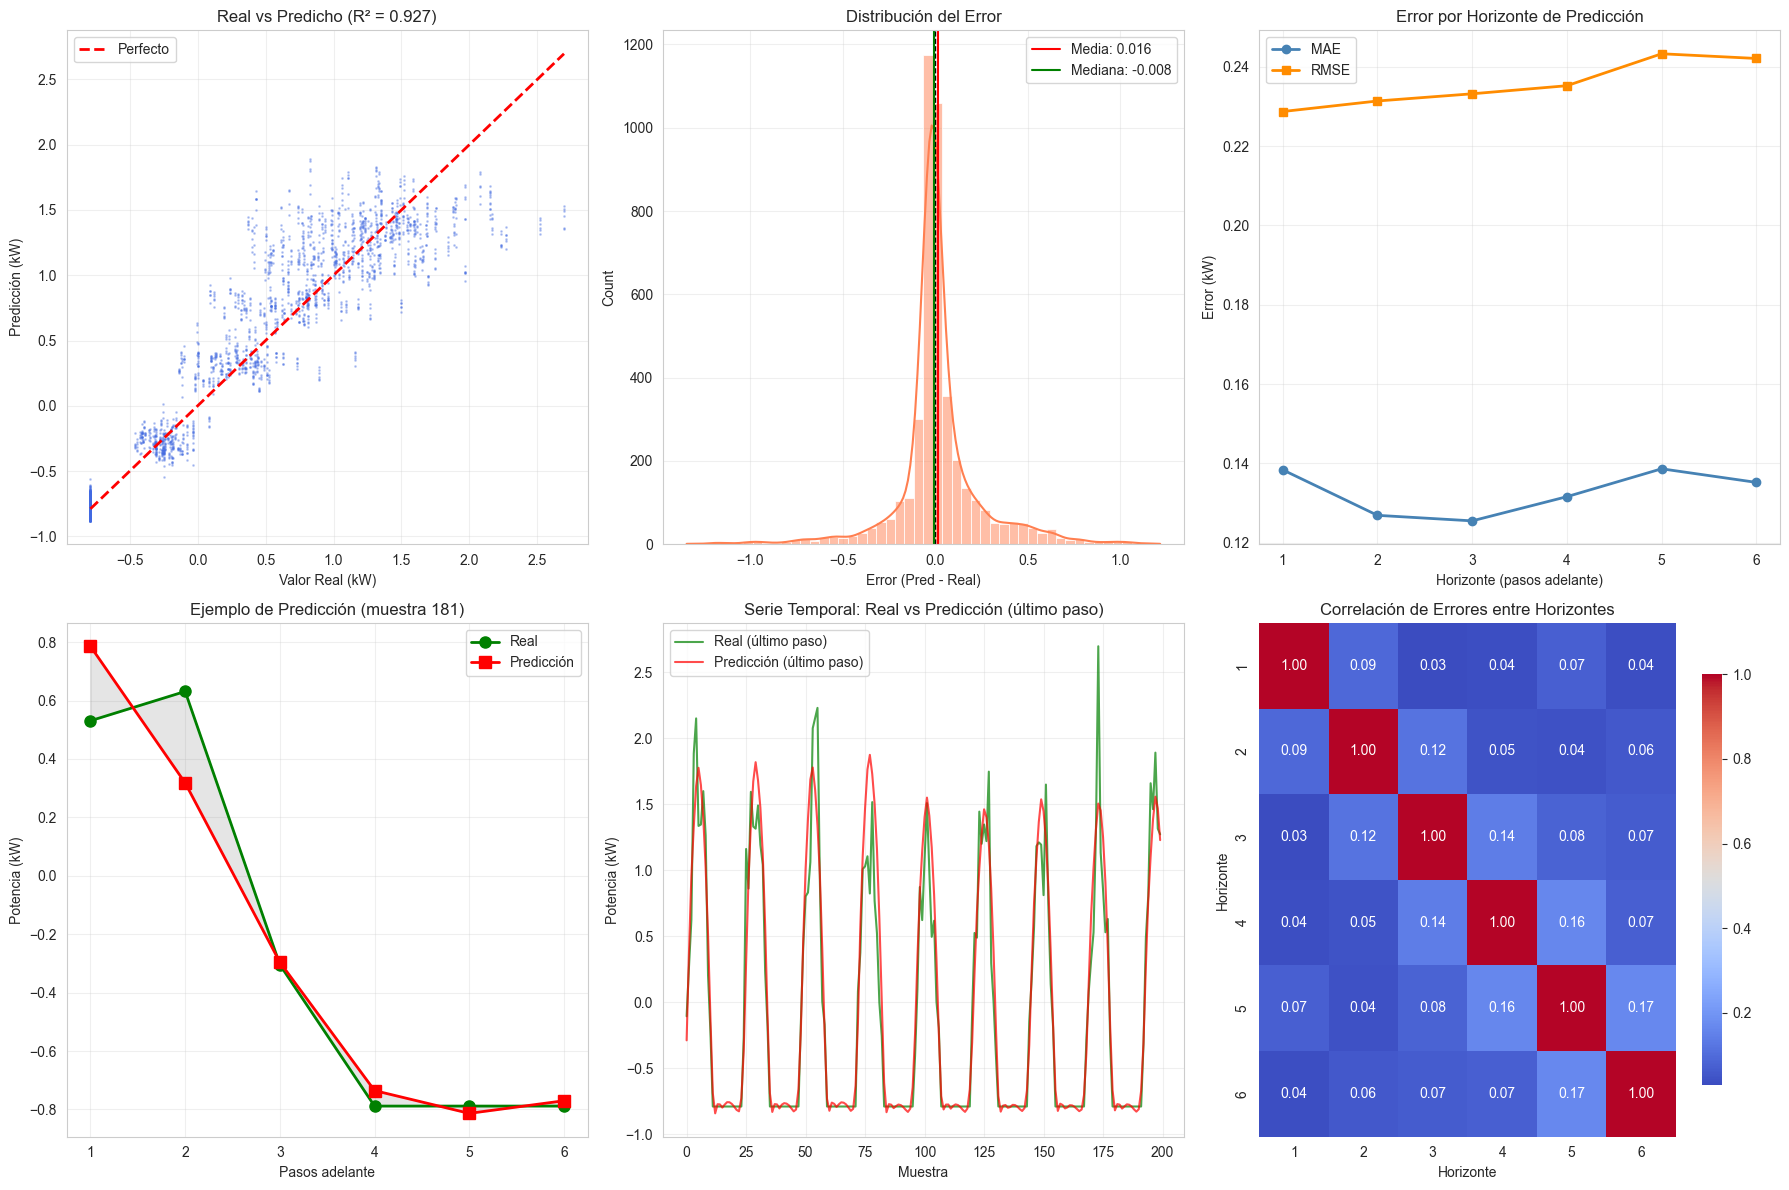

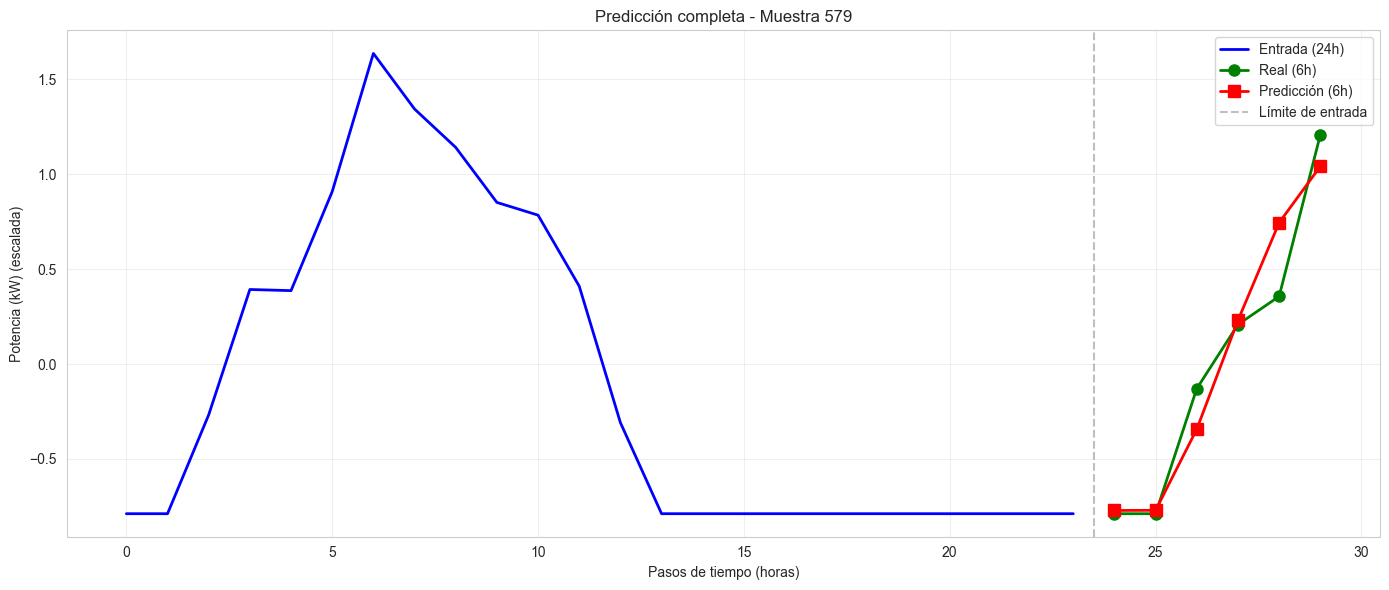

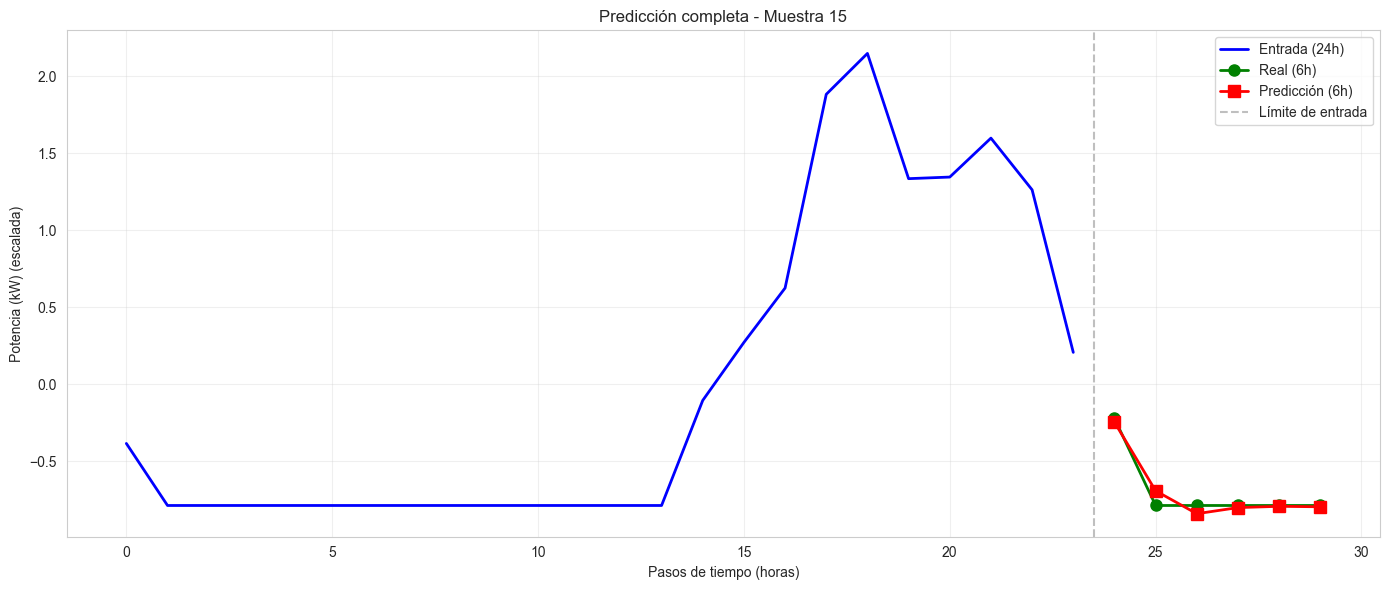

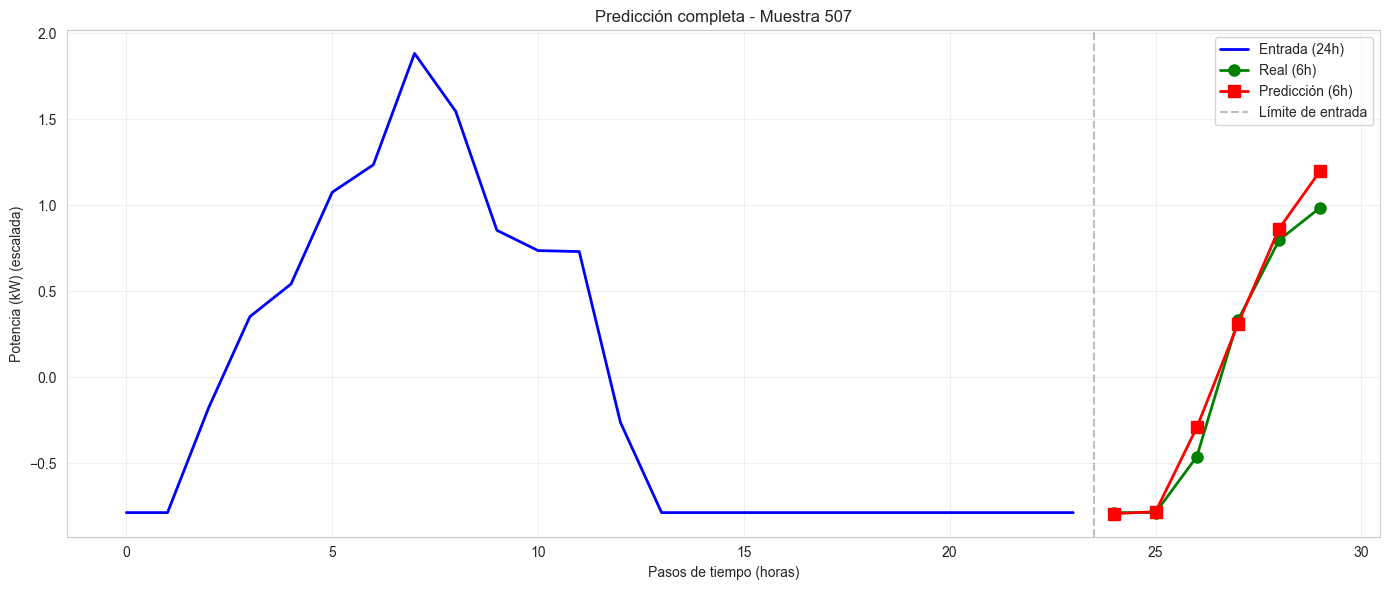

In [71]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# 1. OBTENER PREDICCIONES Y VALORES REALES
# ============================================
def get_predictions(model, dataloader, device='cuda'):
    """Devuelve arrays de predicciones y reales del dataloader."""
    model.eval()
    preds_list = []
    y_true_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)  # (batch, pred_len)
            
            preds_list.append(y_pred.cpu().numpy())
            y_true_list.append(y_batch.numpy())  # y_batch ya está en CPU
    
    # Concatenar todos los batches
    preds = np.concatenate(preds_list, axis=0)   # (n_muestras, pred_len)
    y_true = np.concatenate(y_true_list, axis=0) # (n_muestras, pred_len)
    
    return preds, y_true

# Obtener predicciones sobre test
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
preds, y_true = get_predictions(model, test_loader, device)

print(f"Predicciones: {preds.shape}, Reales: {y_true.shape}")

# ============================================
# 2. MÉTRICAS GLOBALES
# ============================================
# Aplanar para calcular métricas sobre todos los pasos
preds_flat = preds.flatten()
y_true_flat = y_true.flatten()

mae = mean_absolute_error(y_true_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, preds_flat))
r2 = r2_score(y_true_flat, preds_flat)

# MAPE (evita división por cero)
mape = np.mean(np.abs((y_true_flat - preds_flat) / (y_true_flat + 1e-8))) * 100

print("\n" + "="*50)
print("MÉTRICAS GLOBALES (todos los pasos)")
print("="*50)
print(f"MAE:  {mae:.4f} kW")
print(f"RMSE: {rmse:.4f} kW")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f} %")

# ============================================
# 3. MÉTRICAS POR HORIZONTE (paso a paso)
# ============================================
errors_step = []
for step in range(preds.shape[1]):
    mae_step = mean_absolute_error(y_true[:, step], preds[:, step])
    rmse_step = np.sqrt(mean_squared_error(y_true[:, step], preds[:, step]))
    errors_step.append((mae_step, rmse_step))

print("\nMÉTRICAS POR HORIZONTE (paso a paso)")
print("Step\tMAE (kW)\tRMSE (kW)")
for step, (mae_s, rmse_s) in enumerate(errors_step, 1):
    print(f"{step}\t{mae_s:.4f}\t\t{rmse_s:.4f}")

# ============================================
# 4. GRÁFICOS
# ============================================
fig = plt.figure(figsize=(18, 12))

# ---------- Gráfico 1: Real vs Predicho (scatter) ----------
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_true_flat, preds_flat, alpha=0.3, s=1, color='royalblue')
ax1.plot([y_true_flat.min(), y_true_flat.max()], 
         [y_true_flat.min(), y_true_flat.max()], 
         'r--', linewidth=2, label='Perfecto')
ax1.set_xlabel('Valor Real (kW)')
ax1.set_ylabel('Predicción (kW)')
ax1.set_title(f'Real vs Predicho (R² = {r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------- Gráfico 2: Distribución de errores ----------
ax2 = plt.subplot(2, 3, 2)
errors = preds_flat - y_true_flat
sns.histplot(errors, bins=50, kde=True, color='coral', ax=ax2)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.axvline(x=np.mean(errors), color='red', linestyle='-', 
            label=f'Media: {np.mean(errors):.3f}')
ax2.axvline(x=np.median(errors), color='green', linestyle='-', 
            label=f'Mediana: {np.median(errors):.3f}')
ax2.set_xlabel('Error (Pred - Real)')
ax2.set_title('Distribución del Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ---------- Gráfico 3: Error por horizonte ----------
ax3 = plt.subplot(2, 3, 3)
steps = np.arange(1, preds.shape[1] + 1)
mae_steps = [e[0] for e in errors_step]
rmse_steps = [e[1] for e in errors_step]
ax3.plot(steps, mae_steps, 'o-', label='MAE', color='steelblue', linewidth=2)
ax3.plot(steps, rmse_steps, 's-', label='RMSE', color='darkorange', linewidth=2)
ax3.set_xlabel('Horizonte (pasos adelante)')
ax3.set_ylabel('Error (kW)')
ax3.set_title('Error por Horizonte de Predicción')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ---------- Gráfico 4: Ejemplo de predicción (una muestra) ----------
ax4 = plt.subplot(2, 3, 4)
# Tomamos una muestra aleatoria del test
idx = np.random.randint(0, len(preds))
# Graficamos los 6 pasos predichos vs reales
x_steps = np.arange(1, preds.shape[1] + 1)
ax4.plot(x_steps, y_true[idx], 'o-', label='Real', color='green', linewidth=2, markersize=8)
ax4.plot(x_steps, preds[idx], 's-', label='Predicción', color='red', linewidth=2, markersize=8)
ax4.fill_between(x_steps, y_true[idx], preds[idx], alpha=0.2, color='gray')
ax4.set_xlabel('Pasos adelante')
ax4.set_ylabel('Potencia (kW)')
ax4.set_title(f'Ejemplo de Predicción (muestra {idx})')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ---------- Gráfico 5: Serie temporal completa (200 muestras) ----------
ax5 = plt.subplot(2, 3, 5)
# Tomamos las primeras 200 muestras del test (equivalente a 200*24h si son horarias)
n_samples = min(200, len(preds))
time_index = np.arange(n_samples)
# Para graficar solo el último paso predicho (o el promedio de los 6)
# Mostramos el último paso (el más lejano en el tiempo) para ver la tendencia
last_step_pred = preds[:n_samples, -1]
last_step_true = y_true[:n_samples, -1]
ax5.plot(time_index, last_step_true, label='Real (último paso)', color='green', alpha=0.7)
ax5.plot(time_index, last_step_pred, label='Predicción (último paso)', color='red', alpha=0.7)
ax5.set_xlabel('Muestra')
ax5.set_ylabel('Potencia (kW)')
ax5.set_title(f'Serie Temporal: Real vs Predicción (último paso)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# ---------- Gráfico 6: Matriz de correlación de errores ----------
ax6 = plt.subplot(2, 3, 6)
# Calculamos correlación entre errores de diferentes pasos
error_matrix = preds - y_true  # (n_muestras, pred_len)
corr_errors = np.corrcoef(error_matrix, rowvar=False)
sns.heatmap(corr_errors, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar_kws={"shrink": 0.8}, ax=ax6)
ax6.set_xlabel('Horizonte')
ax6.set_ylabel('Horizonte')
ax6.set_title('Correlación de Errores entre Horizontes')
ax6.set_xticklabels(range(1, preds.shape[1]+1))
ax6.set_yticklabels(range(1, preds.shape[1]+1))

plt.tight_layout()
plt.savefig('predicciones_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. GRÁFICO ADICIONAL: COMPARACIÓN COMPLETA (ENTRADA + PREDICCIÓN)
# ============================================
# Para este gráfico necesitamos reconstruir la secuencia completa desde el dataset original.
# Asumimos que test_dataset guarda los índices originales o podemos obtener una muestra.

# Si quieres ver la entrada de 24h + predicción de 6h en una sola gráfica:
def plot_full_prediction(model, test_dataset, idx, device='cuda'):
    """
    Grafica la entrada (seq_len) y la predicción (pred_len) para una muestra dada.
    """
    X_sample, y_sample = test_dataset[idx]
    X_sample = X_sample.unsqueeze(0).to(device)  # (1, seq_len, 5)
    y_true = y_sample.numpy()  # (pred_len,)
    
    with torch.no_grad():
        y_pred = model(X_sample).squeeze().cpu().numpy()  # (pred_len,)
    
    # Reconstruir la secuencia: los features de entrada (la última columna es potencia)
    X_np = X_sample.squeeze().cpu().numpy()  # (seq_len, 5)
    # Graficamos solo la potencia de entrada (última columna)
    input_power = X_np[:, -1]  # potencia pasada
    # Los valores están escalados, necesitamos desescalar. (opcional: si guardaste el scaler)
    # Por simplicidad, graficamos en escala normalizada o puedes desescalar con scaler.inverse_transform
    
    plt.figure(figsize=(14, 6))
    plt.plot(np.arange(len(input_power)), input_power, label='Entrada (24h)', color='blue', linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_true)), 
             y_true, 'o-', label='Real (6h)', color='green', markersize=8, linewidth=2)
    plt.plot(np.arange(len(input_power), len(input_power) + len(y_pred)), 
             y_pred, 's-', label='Predicción (6h)', color='red', markersize=8, linewidth=2)
    plt.axvline(x=len(input_power)-0.5, color='gray', linestyle='--', alpha=0.5, label='Límite de entrada')
    plt.xlabel('Pasos de tiempo (horas)')
    plt.ylabel('Potencia (kW) (escalada)')
    plt.title(f'Predicción completa - Muestra {idx}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ejemplo: graficar 3 muestras aleatorias
for i in np.random.choice(len(test_dataset), 3, replace=False):
    plot_full_prediction(model, test_dataset, i, device)